# TFM 4.2 .- CONTINUACIÓN MODELIZACIÓN
Este notebook continúa el proceso de modelización iniciado en el Notebook 4.1.

Se recuperan las muestras de entrenamiento, validación y test junto con las matrices correspondientes a la Rama A de preprocesamiento.

El conjunto de test permanece reservado y no se utilizará para seleccionar modelos ni hiperparámetros.

In [3]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from IPython.display import display

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    200
)

In [27]:
MODEL_DATA_PATH = Path("data/model")

MODEL_41_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_1_prepared_data.joblib"
)

data_41 = joblib.load(
    MODEL_41_FILE
)

train = data_41["train"]
validation = data_41["validation"]
test = data_41["test"]

y_train = data_41["y_train"]
y_validation = data_41["y_validation"]
y_test = data_41["y_test"]

X_train_A = data_41["X_train_A"]
X_validation_A = data_41["X_validation_A"]
X_test_A = data_41["X_test_A"]

X_train_A_reduced = data_41[
    "X_train_A_reduced"
]

X_validation_A_reduced = data_41[
    "X_validation_A_reduced"
]

X_test_A_reduced = data_41[
    "X_test_A_reduced"
]

linear_results = data_41[
    "linear_results"
]

linear_results_OLS = data_41[
    "linear_results_OLS"
]

linear_results_rating = data_41[
    "linear_results_rating"
]

comparison_rating_model = data_41[
    "comparison_rating_model"
]

In [25]:
print(
    "Train:",
    X_train_A_reduced.shape
)

print(
    "Validation:",
    X_validation_A_reduced.shape
)

print(
    "Test:",
    X_test_A_reduced.shape
)

print(
    "\nObjetivo train:",
    y_train.shape
)

print(
    "Objetivo validation:",
    y_validation.shape
)

print(
    "Objetivo test:",
    y_test.shape
)

print(
    "\nNaN train:",
    X_train_A_reduced.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_A_reduced.isna().sum().sum()
)

print(
    "NaN test:",
    X_test_A_reduced.isna().sum().sum()
)

Train: (2497, 111)
Validation: (466, 111)
Test: (471, 111)

Objetivo train: (2497,)
Objetivo validation: (466,)
Objetivo test: (471,)

NaN train: 0
NaN validation: 0
NaN test: 0


In [6]:
def evaluate_model(y_true, y_pred):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 2. REGRESIÓN RIDGE
> Segundo modelo real perteneciente a la RAMA A

La regresión Ridge amplía la regresión lineal incorporando una penalización L2 sobre el tamaño de los coeficientes.

Esta regularización permite reducir la inestabilidad producida por la multicolinealidad y evitar que determinadas variables correlacionadas generen coeficientes excesivamente elevados.

El parámetro de regularización $(\alpha)$ se selecciona utilizando exclusivamente el conjunto de validación. El conjunto de test permanece reservado para la evaluación final del modelo seleccionado.

In [8]:
X_train_ridge = X_train_A_reduced.copy()
X_validation_ridge = X_validation_A_reduced.copy()
X_test_ridge = X_test_A_reduced.copy()

print("Train:", X_train_ridge.shape)
print("Validation:", X_validation_ridge.shape)
print("Test:", X_test_ridge.shape)

print("NaN train:", X_train_ridge.isna().sum().sum())
print("NaN validation:", X_validation_ridge.isna().sum().sum())
print("NaN test:", X_test_ridge.isna().sum().sum())

Train: (2497, 111)
Validation: (466, 111)
Test: (471, 111)
NaN train: 0
NaN validation: 0
NaN test: 0


In [9]:
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

ridge_alphas = np.logspace(
    -4,
    4,
    81
)

ridge_results = []

for alpha in ridge_alphas:

    model = Ridge(
        alpha=alpha
    )

    model.fit(
        X_train_ridge,
        y_train
    )

    pred = model.predict(
        X_validation_ridge
    )

    metrics = evaluate_model(
        y_validation,
        pred
    )

    ridge_results.append({
        "alpha": alpha,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

ridge_validation_results = pd.DataFrame(
    ridge_results
)

In [10]:
best_ridge_row = (
    ridge_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_ridge_alpha = best_ridge_row["alpha"]

print(
    "Mejor alpha:",
    round(best_ridge_alpha, 6)
)

display(
    best_ridge_row
    .to_frame()
    .T
    .round(4)
)

Mejor alpha: 12.589254


,alpha,MAE,RMSE,R2
51,12.5893,7.2654,10.4239,0.8597


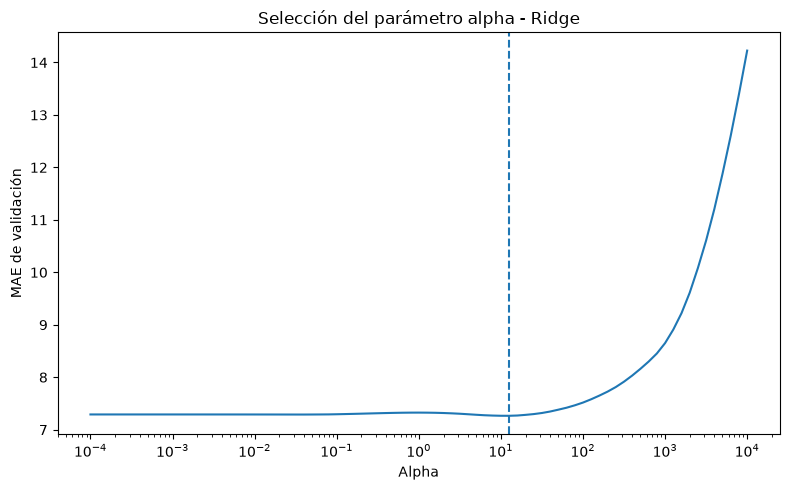

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    ridge_validation_results["alpha"],
    ridge_validation_results["MAE"]
)

plt.axvline(
    best_ridge_alpha,
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("MAE de validación")
plt.title("Selección del parámetro alpha - Ridge")

plt.tight_layout()
plt.show()

In [12]:
ridge_model = Ridge(
    alpha=best_ridge_alpha
)

ridge_model.fit(
    X_train_ridge,
    y_train
)

ridge_validation_pred = ridge_model.predict(
    X_validation_ridge
)

ridge_results_final = evaluate_model(
    y_validation,
    ridge_validation_pred
)

display(
    pd.DataFrame(
        [ridge_results_final],
        index=["Ridge - fundamentales"]
    ).round(3)
)

,MAE,RMSE,R2
Ridge - fundamentales,7.265,10.424,0.86


In [26]:
comparison_ridge = pd.DataFrame({
    "OLS original": linear_results,
    "OLS depurada": linear_results_OLS,
    "Ridge": ridge_results_final
}).T

display(
    comparison_ridge.round(3)
)

,MAE,RMSE,R2
OLS original,7.261,10.456,0.859
OLS depurada,8.486,11.760,0.821
Ridge,7.265,10.424,0.860


In [14]:
ridge_validation_results_df = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

ridge_validation_results_df["rating_year"] = (
    ridge_validation_results_df["year"] + 1
)

ridge_validation_results_df["prediction"] = (
    ridge_validation_pred
)

ridge_validation_results_df["residual"] = (
    ridge_validation_results_df["rating_score_mean_t1"]
    - ridge_validation_results_df["prediction"]
)

ridge_validation_results_df["absolute_error"] = (
    ridge_validation_results_df["residual"].abs()
)

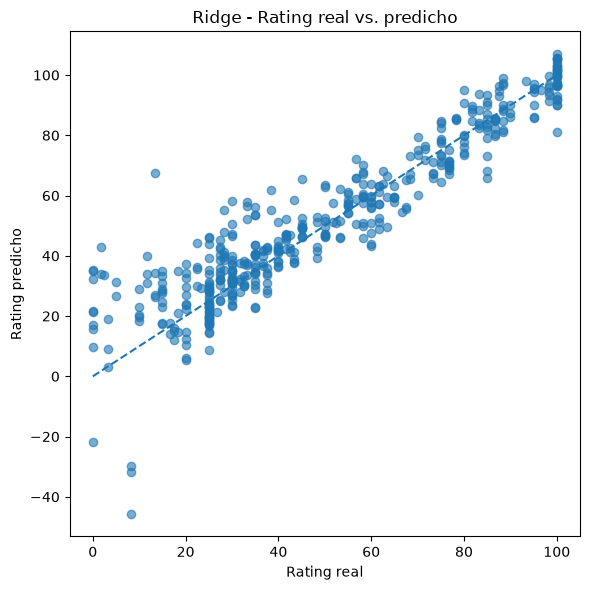

In [15]:
plt.figure(figsize=(6, 6))

plt.scatter(
    ridge_validation_results_df["rating_score_mean_t1"],
    ridge_validation_results_df["prediction"],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")
plt.title("Ridge - Rating real vs. predicho")

plt.tight_layout()
plt.show()

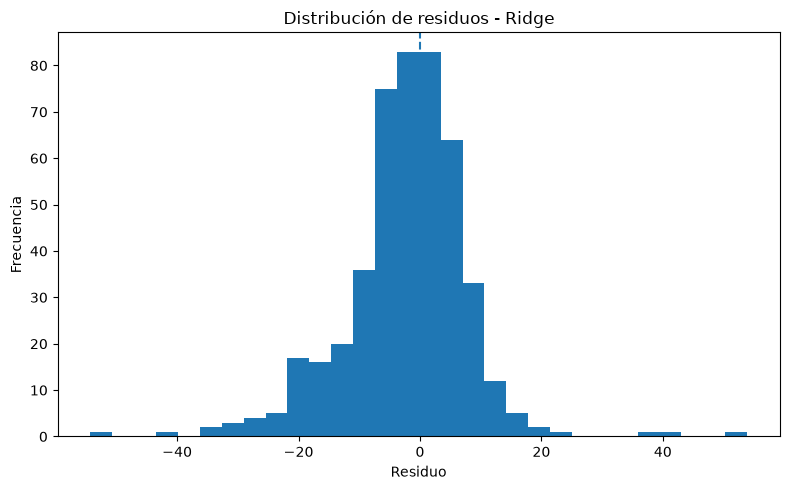

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    ridge_validation_results_df["residual"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos - Ridge")

plt.tight_layout()
plt.show()

,MAE
rating_year,
2020,7.080
2021,6.796
2022,7.916


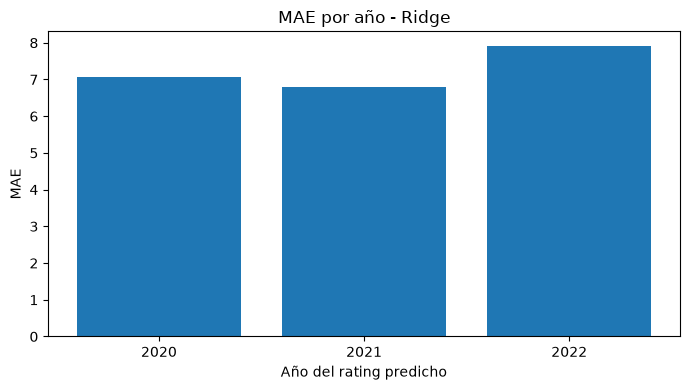

In [17]:
ridge_error_year = (
    ridge_validation_results_df
    .groupby("rating_year")["absolute_error"]
    .mean()
)

display(
    ridge_error_year
    .to_frame("MAE")
    .round(3)
)

plt.figure(figsize=(7, 4))

plt.bar(
    ridge_error_year.index.astype(str),
    ridge_error_year.values
)

plt.xlabel("Año del rating predicho")
plt.ylabel("MAE")
plt.title("MAE por año - Ridge")

plt.tight_layout()
plt.show()

In [18]:
worst_ridge_predictions = (
    ridge_validation_results_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_ridge_predictions[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,67.60,54.27
3379,"Venezuela, RB",2020,2021,8.33,-45.56,53.89
409,Belarus,2021,2022,1.67,42.84,41.17
3378,"Venezuela, RB",2019,2020,8.33,-31.67,40.00
3380,"Venezuela, RB",2021,2022,8.33,-29.74,38.07
2657,Puerto Rico (US),2021,2022,0.00,35.27,35.27
2655,Puerto Rico (US),2019,2020,0.00,35.01,35.01
1908,Sri Lanka,2021,2022,1.67,33.98,32.32
2656,Puerto Rico (US),2020,2021,0.00,32.29,32.29
1229,Ghana,2021,2022,2.50,33.53,31.03


In [19]:
outside_ridge = (
    (ridge_validation_pred < 0)
    |
    (ridge_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_ridge.sum()
)

print(
    "Porcentaje:",
    round(
        outside_ridge.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(ridge_validation_pred.min(), 2)
)

print(
    "Predicción máxima:",
    round(ridge_validation_pred.max(), 2)
)

Predicciones fuera de 0-100: 18
Porcentaje: 3.86 %
Predicción mínima: -45.56
Predicción máxima: 106.9


In [20]:
ridge_coefficients = pd.DataFrame({
    "variable": X_train_ridge.columns,
    "coefficient": ridge_model.coef_
})

ridge_coefficients["absolute_coefficient"] = (
    ridge_coefficients["coefficient"].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ridge_coefficients
    .head(20)
    .round(4)
)

,variable,coefficient,absolute_coefficient
0,regulatory_quality_estimate,14.3168,14.3168
1,gdp_per_capita_constant_2015_usd,12.5099,12.5099
2,gdp_ppp_constant_2021_intl_usd,8.5682,8.5682
3,missingindicator_control_of_corruption_estimate,8.5326,8.5326
4,missingindicator_inflation_cpi_pct,-8.0566,8.0566
5,never_default_history_dummy,6.0461,6.0461
6,missingindicator_unemployment_pct,5.7187,5.7187
7,government_expenditure_pct_gdp,5.0047,5.0047
8,region_Sub-Saharan Africa,4.9872,4.9872
9,missingindicator_gdp_per_capita_constant_2015_usd,4.5909,4.5909


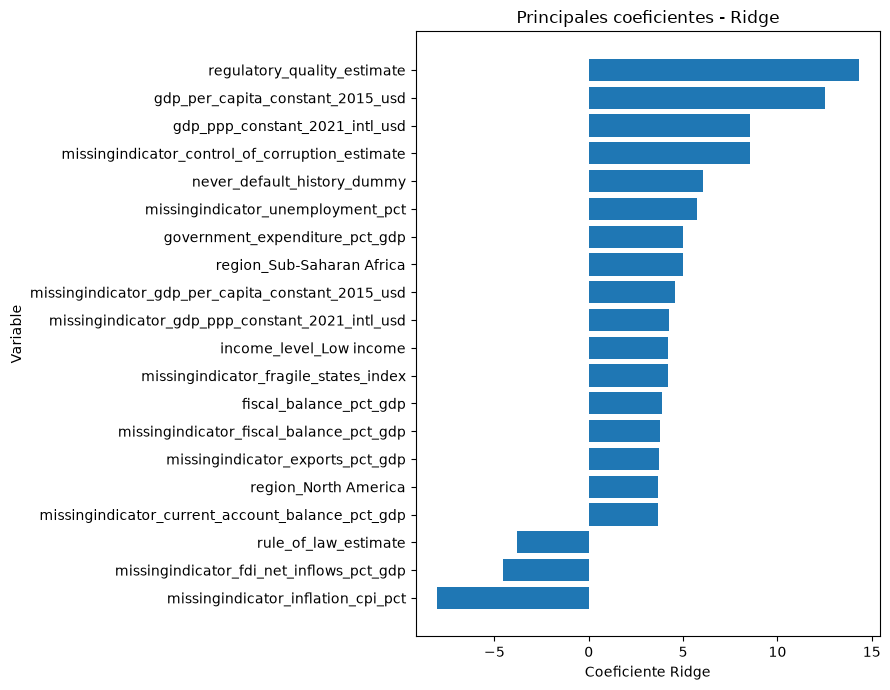

In [21]:
top_ridge_variables = (
    ridge_coefficients
    .head(20)
    .sort_values("coefficient")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_ridge_variables["variable"],
    top_ridge_variables["coefficient"]
)

plt.xlabel("Coeficiente Ridge")
plt.ylabel("Variable")
plt.title("Principales coeficientes - Ridge")

plt.tight_layout()
plt.show()

In [22]:
ridge_permutation = permutation_importance(
    ridge_model,
    X_validation_ridge,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

ridge_importance = pd.DataFrame({
    "variable": X_validation_ridge.columns,
    "importance": ridge_permutation.importances_mean
})

ridge_importance = (
    ridge_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ridge_importance
    .head(20)
    .round(4)
)

,variable,importance
0,regulatory_quality_estimate,6.3979
1,gdp_per_capita_constant_2015_usd,4.7563
2,gdp_ppp_constant_2021_intl_usd,3.2209
3,fiscal_balance_pct_gdp,1.5482
4,primary_balance_pct_gdp,1.4825
5,inflation_abs,0.9784
6,government_debt_pct_gdp,0.9610
7,imports_pct_gdp,0.9120
8,government_expenditure_pct_gdp,0.8520
9,exports_pct_gdp,0.8425


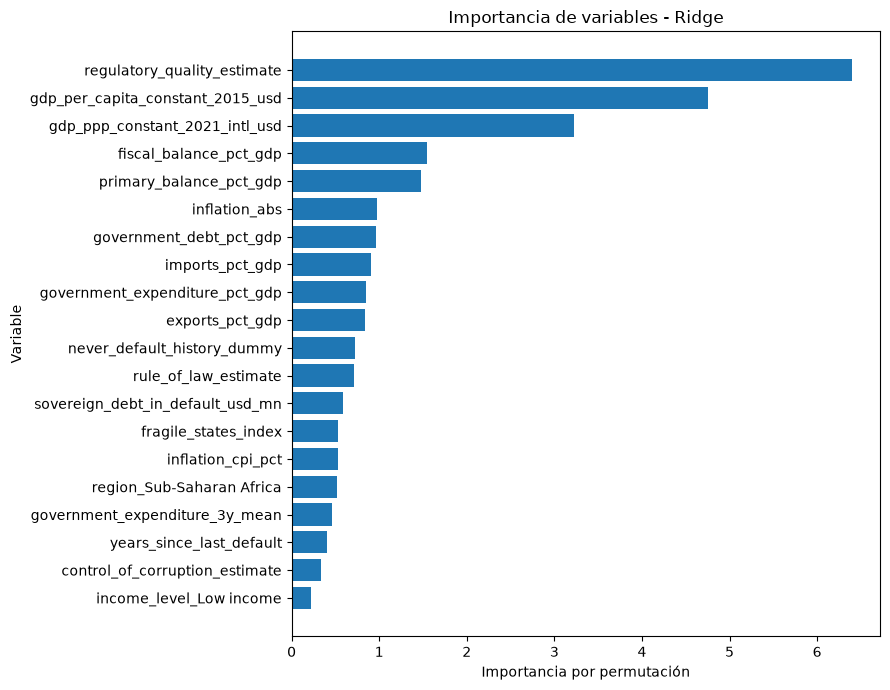

In [23]:
top_ridge_importance = (
    ridge_importance
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_ridge_importance["variable"],
    top_ridge_importance["importance"]
)

plt.xlabel("Importancia por permutación")
plt.ylabel("Variable")
plt.title("Importancia de variables - Ridge")

plt.tight_layout()
plt.show()

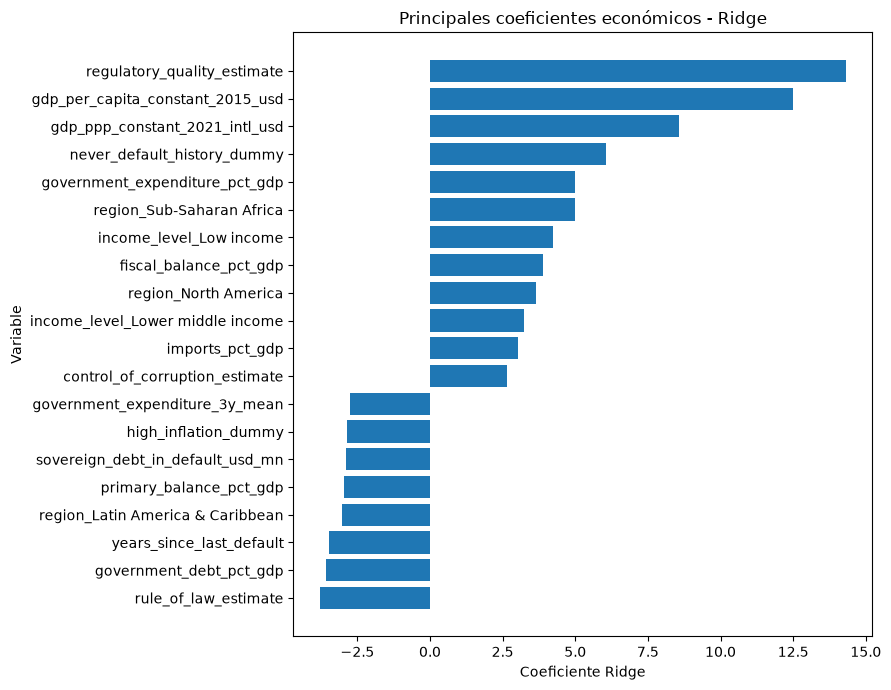

In [28]:
ridge_coefficients_economic = (
    ridge_coefficients[
        ~ridge_coefficients["variable"]
        .str.startswith("missingindicator_")
    ]
    .head(20)
    .sort_values("coefficient")
)

plt.figure(figsize=(9, 7))

plt.barh(
    ridge_coefficients_economic["variable"],
    ridge_coefficients_economic["coefficient"]
)

plt.xlabel("Coeficiente Ridge")
plt.ylabel("Variable")
plt.title(
    "Principales coeficientes económicos - Ridge"
)

plt.tight_layout()
plt.show()

La regresión Ridge alcanza un MAE de 7,265 y un $R^2$
 de 0,860 en validación, ofreciendo un rendimiento prácticamente equivalente al de la regresión lineal sin regularización. El valor óptimo del parámetro de penalización se sitúa en α=12,589. La regularización permite mantener conjuntamente variables correlacionadas sin generar la inestabilidad observada en la estimación OLS orientada a inferencia, aunque no proporciona una mejora sustancial de la capacidad predictiva.

El análisis de importancia por permutación vuelve a destacar indicadores institucionales, de desarrollo económico y fiscales. Entre las variables con mayor contribución predictiva aparecen la calidad regulatoria, el PIB per cápita, el PIB PPA, el saldo fiscal, la deuda pública y diferentes indicadores relacionados con inflación y comercio exterior. El modelo mantiene, no obstante, dificultades importantes en economías con ratings muy bajos o sometidas a episodios extremos, y continúa generando algunas predicciones fuera del intervalo teórico 0–100.

In [29]:
from sklearn.preprocessing import StandardScaler

train_rating_index = train[
    train["rating_score_mean_t"].notna()
].index

validation_rating_index = validation[
    validation["rating_score_mean_t"].notna()
].index

X_train_ridge_rating = (
    X_train_ridge
    .loc[train_rating_index]
    .copy()
)

X_validation_ridge_rating = (
    X_validation_ridge
    .loc[validation_rating_index]
    .copy()
)

y_train_ridge_rating = (
    y_train.loc[train_rating_index]
)

y_validation_ridge_rating = (
    y_validation.loc[validation_rating_index]
)

In [30]:
rating_scaler_ridge = StandardScaler()

X_train_ridge_rating[
    "rating_score_mean_t"
] = rating_scaler_ridge.fit_transform(
    train.loc[
        train_rating_index,
        ["rating_score_mean_t"]
    ]
).ravel()

X_validation_ridge_rating[
    "rating_score_mean_t"
] = rating_scaler_ridge.transform(
    validation.loc[
        validation_rating_index,
        ["rating_score_mean_t"]
    ]
).ravel()

In [31]:
ridge_rating_results = []

for alpha in ridge_alphas:

    model = Ridge(
        alpha=alpha
    )

    model.fit(
        X_train_ridge_rating,
        y_train_ridge_rating
    )

    pred = model.predict(
        X_validation_ridge_rating
    )

    metrics = evaluate_model(
        y_validation_ridge_rating,
        pred
    )

    ridge_rating_results.append({
        "alpha": alpha,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

ridge_rating_validation_results = pd.DataFrame(
    ridge_rating_results
)

best_ridge_rating_row = (
    ridge_rating_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_ridge_rating_alpha = (
    best_ridge_rating_row["alpha"]
)

print(
    "Mejor alpha:",
    best_ridge_rating_alpha
)

display(
    best_ridge_rating_row
    .to_frame()
    .T
    .round(4)
)

Mejor alpha: 6.309573444801943


,alpha,MAE,RMSE,R2
48,6.3096,2.4787,4.6178,0.9724


In [32]:
ridge_model_rating = Ridge(
    alpha=best_ridge_rating_alpha
)

ridge_model_rating.fit(
    X_train_ridge_rating,
    y_train_ridge_rating
)

ridge_validation_pred_rating = (
    ridge_model_rating.predict(
        X_validation_ridge_rating
    )
)

ridge_results_rating = evaluate_model(
    y_validation_ridge_rating,
    ridge_validation_pred_rating
)

In [33]:
comparison_rating_ridge = (
    comparison_rating_model.copy()
)

comparison_rating_ridge.loc[
    "Ridge + rating_t"
] = ridge_results_rating

display(
    comparison_rating_ridge.round(3)
)

,MAE,RMSE,R2
Media,25.223,28.717,-0.066
Persistencia,1.505,4.209,0.977
Fundamentales,8.478,11.761,0.821
Fundamentales + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972


In [35]:
# Observaciones de validación con rating previo disponible

changed_validation = validation.loc[
    validation_rating_index
].copy()

# Cambio entre t y t+1

changed_validation["rating_change_t1"] = (
    changed_validation["rating_score_mean_t1"]
    - changed_validation["rating_score_mean_t"]
)

# Solo observaciones donde cambia el rating

changed_validation = changed_validation[
    changed_validation["rating_change_t1"] != 0
].copy()

print(
    "Observaciones con cambio:",
    len(changed_validation)
)

Observaciones con cambio: 137


In [39]:
comparison_changed = pd.DataFrame({
    "MAE": [
        5.097,
        4.951
    ],
    "RMSE": [
        7.746,
        7.736
    ],
    "R2": [
        0.897,
        0.897
    ]
}, index=[
    "Persistencia",
    "Fundamentales + rating_t"
])

display(
    comparison_changed
)

,MAE,RMSE,R2
Persistencia,5.097,7.746,0.897
Fundamentales + rating_t,4.951,7.736,0.897


In [40]:
ridge_rating_predictions = pd.Series(
    ridge_validation_pred_rating,
    index=validation_rating_index
)

changed_index = changed_validation.index

ridge_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    ridge_rating_predictions.loc[
        changed_index
    ]
)

comparison_changed_ridge = (
    comparison_changed.copy()
)

comparison_changed_ridge.loc[
    "Ridge + rating_t"
] = ridge_changed_results

display(
    comparison_changed_ridge.round(3)
)

,MAE,RMSE,R2
Persistencia,5.097,7.746,0.897
Fundamentales + rating_t,4.951,7.736,0.897
Ridge + rating_t,4.857,7.815,0.895


In [42]:
data_42 = {
    "comparison_rating_ridge":
        comparison_rating_ridge,

    "comparison_changed_ridge":
        comparison_changed_ridge,

    "ridge_results_final":
        ridge_results_final,

    "ridge_results_rating":
        ridge_results_rating,

    "best_ridge_alpha":
        best_ridge_alpha,

    "best_ridge_rating_alpha":
        best_ridge_rating_alpha
}

joblib.dump(
    data_42,
    MODEL_DATA_PATH / "notebook_4_2_results.joblib"
)

['data\\model\\notebook_4_2_results.joblib']

Al incorporar la calificación crediticia del año anterior, el valor óptimo del parámetro de regularización Ridge se sitúa en (\alpha=6,31). En el conjunto completo de validación, el modelo alcanza un MAE de 2,479, un RMSE de 4,618 y un (R^2) de 0,972. Estos resultados son ligeramente inferiores a los obtenidos por la regresión lineal con fundamentales y rating previo, cuyo MAE es de 2,402, y tampoco permiten superar el baseline de persistencia, con un MAE de 1,505.

Sin embargo, el resultado cambia al considerar exclusivamente las observaciones en las que se produce una modificación de la calificación crediticia. En este subconjunto, Ridge alcanza un MAE de 4,857, mejorando tanto a la regresión lineal con rating previo (4,951) como al modelo de persistencia (5,097).

Por tanto, aunque la regularización Ridge no mejora la predicción global del nivel de rating, sí muestra una ligera ventaja en términos de error absoluto cuando se producen cambios efectivos de calificación. Este resultado sugiere que la regularización puede facilitar la extracción de información adicional de los fundamentales en aquellas observaciones en las que la elevada persistencia de los ratings deja de ser suficiente para realizar la predicción.


MAE en cambios: $5.097(Persistencia)>4.951(OLS)>4.857(Ridge)$


## 3. REGRESIÓN LASSO
> Tercer modelo real perteneciente a la RAMA A

La diferencia interesante es que Lasso aplica penalización L1 y puede llevar coeficientes exactamente a cero, así que aquí podremos analizar también selección automática de variables.

In [43]:
from sklearn.linear_model import Lasso
from sklearn.inspection import permutation_importance

X_train_lasso = X_train_ridge.copy()
X_validation_lasso = X_validation_ridge.copy()
X_test_lasso = X_test_ridge.copy()

print("Train:", X_train_lasso.shape)
print("Validation:", X_validation_lasso.shape)
print("Test:", X_test_lasso.shape)

Train: (2497, 111)
Validation: (466, 111)
Test: (471, 111)


In [44]:
lasso_alphas = np.logspace(
    -4,
    2,
    81
)

lasso_results = []

for alpha in lasso_alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=50000
    )

    model.fit(
        X_train_lasso,
        y_train
    )

    pred = model.predict(
        X_validation_lasso
    )

    metrics = evaluate_model(
        y_validation,
        pred
    )

    n_variables = np.sum(
        model.coef_ != 0
    )

    lasso_results.append({
        "alpha": alpha,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "variables": n_variables
    })

lasso_validation_results = pd.DataFrame(
    lasso_results
)

In [45]:
best_lasso_row = (
    lasso_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_lasso_alpha = (
    best_lasso_row["alpha"]
)

print(
    "Mejor alpha:",
    best_lasso_alpha
)

display(
    best_lasso_row
    .to_frame()
    .T
    .round(4)
)

Mejor alpha: 0.11885022274370177


,alpha,MAE,RMSE,R2,variables
41,0.1189,7.1675,10.5859,0.8553,55.0


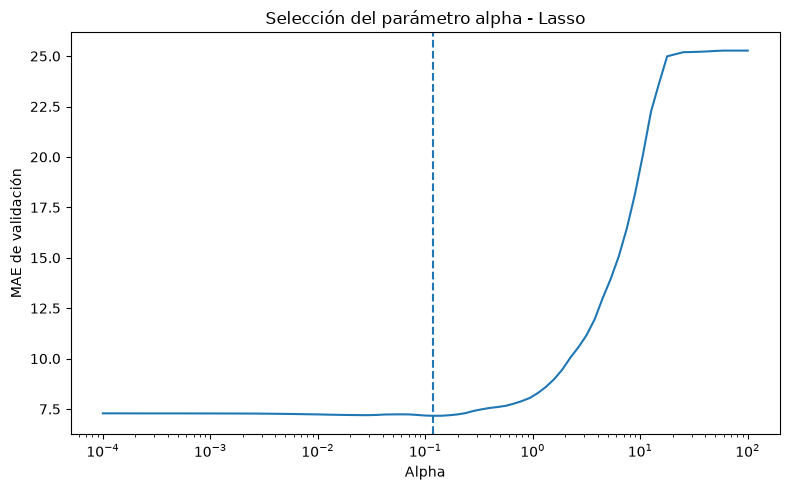

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    lasso_validation_results["alpha"],
    lasso_validation_results["MAE"]
)

plt.axvline(
    best_lasso_alpha,
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("MAE de validación")
plt.title("Selección del parámetro alpha - Lasso")

plt.tight_layout()
plt.show()

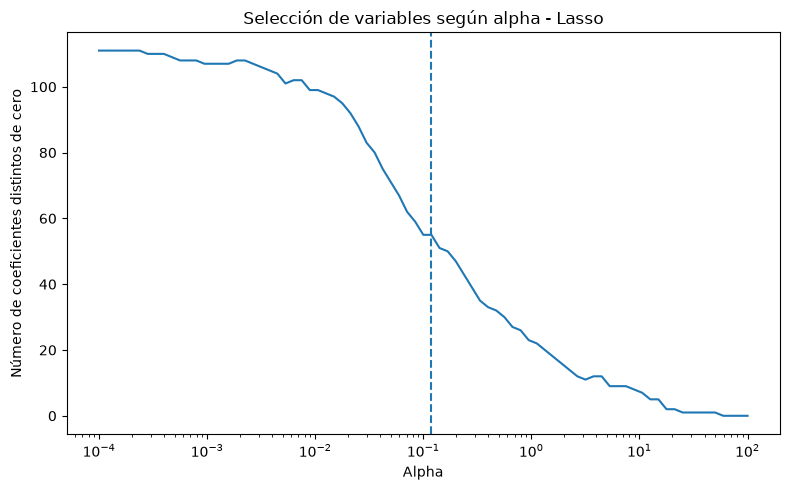

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    lasso_validation_results["alpha"],
    lasso_validation_results["variables"]
)

plt.axvline(
    best_lasso_alpha,
    linestyle="--"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Número de coeficientes distintos de cero")
plt.title("Selección de variables según alpha - Lasso")

plt.tight_layout()
plt.show()

In [48]:
lasso_model = Lasso(
    alpha=best_lasso_alpha,
    max_iter=50000
)

lasso_model.fit(
    X_train_lasso,
    y_train
)

lasso_validation_pred = (
    lasso_model.predict(
        X_validation_lasso
    )
)

lasso_results_final = evaluate_model(
    y_validation,
    lasso_validation_pred
)

display(
    pd.DataFrame(
        [lasso_results_final],
        index=["Lasso"]
    ).round(3)
)

,MAE,RMSE,R2
Lasso,7.167,10.586,0.855


In [49]:
comparison_regularized = pd.DataFrame({
    "OLS original": linear_results,
    "OLS depurada": linear_results_OLS,
    "Ridge": ridge_results_final,
    "Lasso": lasso_results_final
}).T

display(
    comparison_regularized.round(3)
)

,MAE,RMSE,R2
OLS original,7.261,10.456,0.859
OLS depurada,8.486,11.760,0.821
Ridge,7.265,10.424,0.860
Lasso,7.167,10.586,0.855


In [50]:
lasso_coefficients = pd.DataFrame({
    "variable": X_train_lasso.columns,
    "coefficient": lasso_model.coef_
})

lasso_coefficients["absolute_coefficient"] = (
    lasso_coefficients["coefficient"].abs()
)

n_total = len(
    lasso_coefficients
)

n_selected = (
    lasso_coefficients["coefficient"] != 0
).sum()

n_removed = (
    lasso_coefficients["coefficient"] == 0
).sum()

print(
    "Variables totales:",
    n_total
)

print(
    "Variables seleccionadas:",
    n_selected
)

print(
    "Variables eliminadas:",
    n_removed
)

print(
    "Porcentaje eliminado:",
    round(
        n_removed / n_total * 100,
        2
    ),
    "%"
)

Variables totales: 111
Variables seleccionadas: 55
Variables eliminadas: 56
Porcentaje eliminado: 50.45 %


In [51]:
lasso_selected = (
    lasso_coefficients[
        lasso_coefficients["coefficient"] != 0
    ]
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    lasso_selected
    .head(25)
    .round(4)
)

,variable,coefficient,absolute_coefficient
0,regulatory_quality_estimate,15.2158,15.2158
1,gdp_per_capita_constant_2015_usd,8.2852,8.2852
2,gdp_ppp_constant_2021_intl_usd,8.1979,8.1979
3,missingindicator_unemployment_pct,7.1584,7.1584
4,never_default_history_dummy,4.6424,4.6424
5,missingindicator_control_of_corruption_estimate,4.0667,4.0667
6,region_Sub-Saharan Africa,3.6868,3.6868
7,government_debt_pct_gdp,-3.4204,3.4204
8,missingindicator_fiscal_balance_pct_gdp,3.3263,3.3263
9,missingindicator_inflation_cpi_pct,-3.1005,3.1005


In [52]:
lasso_selected_economic = (
    lasso_selected[
        ~lasso_selected["variable"]
        .str.startswith("missingindicator_")
    ]
)

display(
    lasso_selected_economic
    .head(20)
    .round(4)
)

,variable,coefficient,absolute_coefficient
0,regulatory_quality_estimate,15.2158,15.2158
1,gdp_per_capita_constant_2015_usd,8.2852,8.2852
2,gdp_ppp_constant_2021_intl_usd,8.1979,8.1979
4,never_default_history_dummy,4.6424,4.6424
6,region_Sub-Saharan Africa,3.6868,3.6868
7,government_debt_pct_gdp,-3.4204,3.4204
10,sovereign_debt_in_default_usd_mn,-2.8227,2.8227
14,region_Latin America & Caribbean,-2.4565,2.4565
15,government_expenditure_pct_gdp,2.4296,2.4296
16,control_of_corruption_estimate,2.1506,2.1506


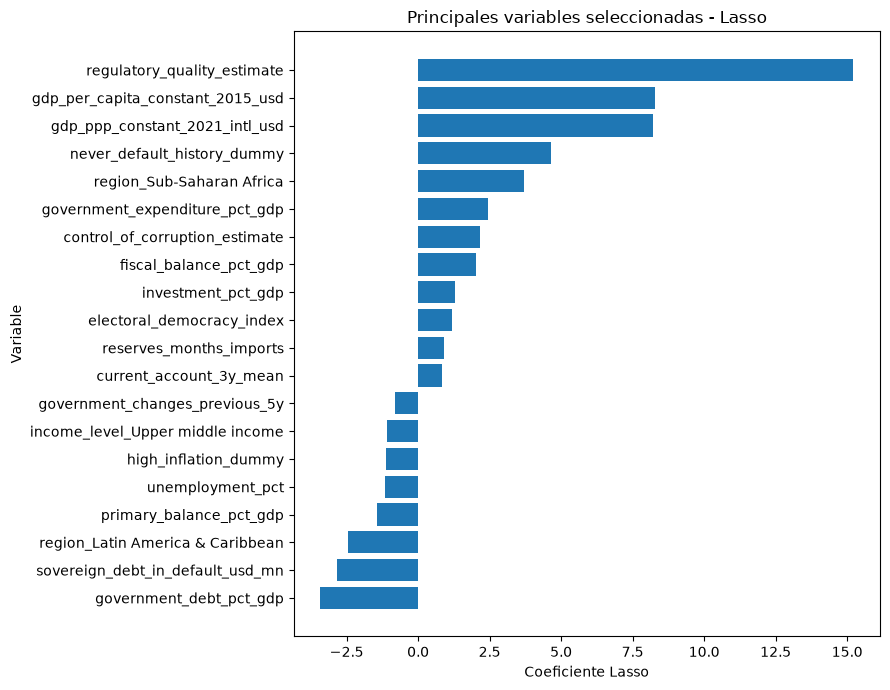

In [53]:
top_lasso_variables = (
    lasso_selected_economic
    .head(20)
    .sort_values("coefficient")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_lasso_variables["variable"],
    top_lasso_variables["coefficient"]
)

plt.xlabel("Coeficiente Lasso")
plt.ylabel("Variable")
plt.title("Principales variables seleccionadas - Lasso")

plt.tight_layout()
plt.show()

In [54]:
lasso_validation_results_df = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

lasso_validation_results_df["rating_year"] = (
    lasso_validation_results_df["year"] + 1
)

lasso_validation_results_df["prediction"] = (
    lasso_validation_pred
)

lasso_validation_results_df["residual"] = (
    lasso_validation_results_df["rating_score_mean_t1"]
    - lasso_validation_results_df["prediction"]
)

lasso_validation_results_df["absolute_error"] = (
    lasso_validation_results_df["residual"].abs()
)

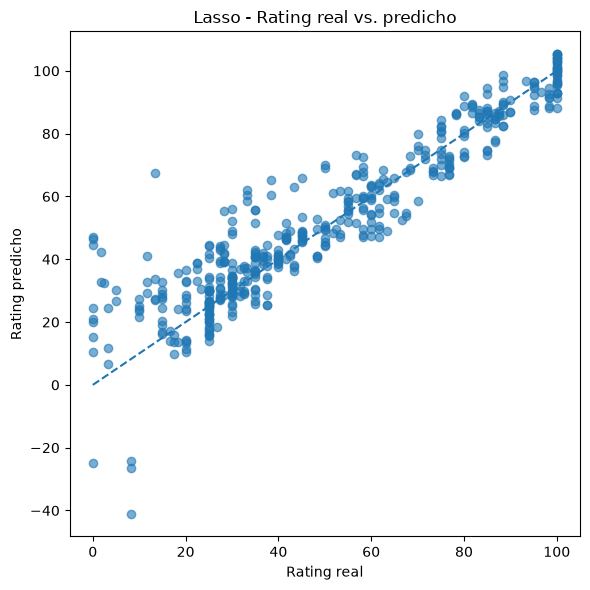

In [55]:
plt.figure(figsize=(6, 6))

plt.scatter(
    lasso_validation_results_df["rating_score_mean_t1"],
    lasso_validation_results_df["prediction"],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")
plt.title("Lasso - Rating real vs. predicho")

plt.tight_layout()
plt.show()

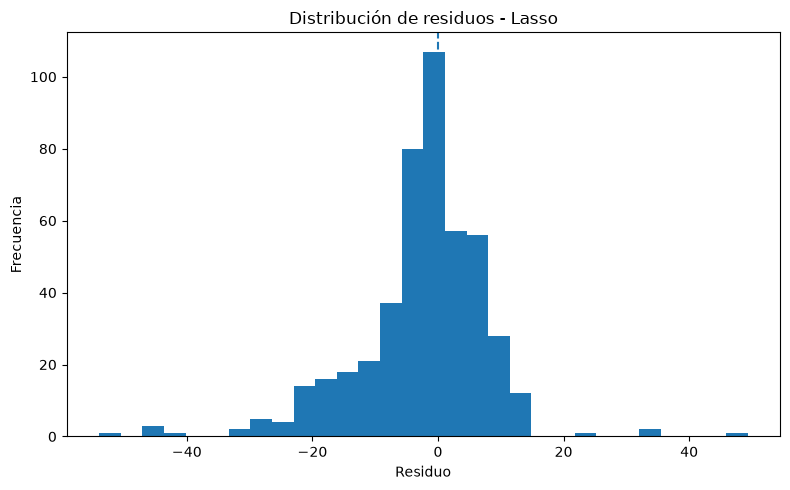

In [56]:
plt.figure(figsize=(8, 5))

plt.hist(
    lasso_validation_results_df["residual"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos - Lasso")

plt.tight_layout()
plt.show()

,MAE
rating_year,
2020,7.135
2021,6.559
2022,7.804


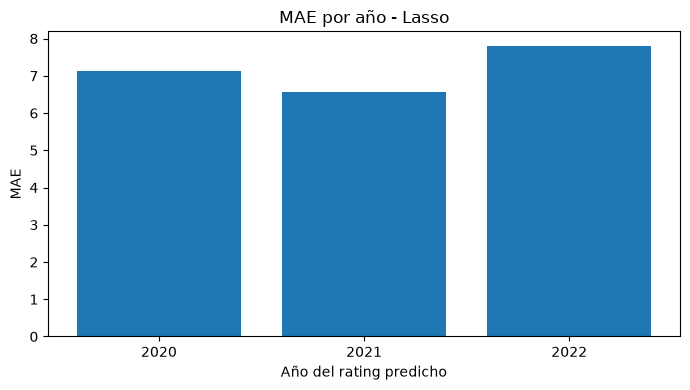

In [57]:
lasso_error_year = (
    lasso_validation_results_df
    .groupby("rating_year")["absolute_error"]
    .mean()
)

display(
    lasso_error_year
    .to_frame("MAE")
    .round(3)
)

plt.figure(figsize=(7, 4))

plt.bar(
    lasso_error_year.index.astype(str),
    lasso_error_year.values
)

plt.xlabel("Año del rating predicho")
plt.ylabel("MAE")
plt.title("MAE por año - Lasso")

plt.tight_layout()
plt.show()

In [58]:
worst_lasso_predictions = (
    lasso_validation_results_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_lasso_predictions[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,67.31,53.98
3379,"Venezuela, RB",2020,2021,8.33,-40.97,49.30
2655,Puerto Rico (US),2019,2020,0.00,46.94,46.94
2657,Puerto Rico (US),2021,2022,0.00,46.32,46.32
2656,Puerto Rico (US),2020,2021,0.00,44.67,44.67
409,Belarus,2021,2022,1.67,42.18,40.51
3380,"Venezuela, RB",2021,2022,8.33,-26.38,34.71
3378,"Venezuela, RB",2019,2020,8.33,-24.32,32.65
1908,Sri Lanka,2021,2022,1.67,32.91,31.24
1229,Ghana,2021,2022,2.50,32.44,29.94


In [59]:
outside_lasso = (
    (lasso_validation_pred < 0)
    |
    (lasso_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_lasso.sum()
)

print(
    "Porcentaje:",
    round(
        outside_lasso.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(
        lasso_validation_pred.min(),
        2
    )
)

print(
    "Predicción máxima:",
    round(
        lasso_validation_pred.max(),
        2
    )
)

Predicciones fuera de 0-100: 20
Porcentaje: 4.29 %
Predicción mínima: -40.97
Predicción máxima: 105.27


El resultado es bastante interesante:
$$
MAE=7.167,RMSE=10.586,R^2=0.855
$$
Por MAE, Lasso es hasta ahora el mejor de los modelos lineales que utilizan únicamente fundamentales:

| Modelo       | MAE   | RMSE   | R²    |
|--------------|-------|--------|-------|
| OLS original | 7.261 | 10.456 | 0.859 |
| Ridge        | 7.265 | 10.424 | 0.860 |
| Lasso        | 7.167 | 10.586 | 0.855 |

No gana en RMSE ni en $R^2$, pero sí en nuestro criterio principal, MAE.

Además, aquí aparece la gran ventaja de Lasso: de 111 variables conserva solo 55 y elimina 56, es decir: **50.45%** de los predictores reciben coeficiente exactamente cero. Por tanto, obtenemos un modelo algo más parsimonioso y con un MAE ligeramente mejor.

En las variables seleccionadas vuelven a aparecer patrones que ya estamos viendo de forma bastante consistente: regulatory_quality_estimate, PIB per cápita, PIB PPA, historial de default, deuda pública, saldo fiscal, inversión, democracia, reservas e inflación. Esto refuerza la relevancia recurrente de los bloques institucional, económico, fiscal y de historial crediticio.

También me gusta que Lasso haya escogido:

| Variable                           | Efecto   |
|------------------------------------|----------|
| government_debt_pct_gdp            | Negativo |
| sovereign_debt_in_default_usd_mn   | Negativo |
| unemployment_pct                   | Negativo |
| high_inflation_dummy               | Negativo |

porque son signos bastante coherentes económicamente. En cambio, seguimos sin interpretar los coeficientes como relaciones causales.

Los errores vuelven a contar prácticamente la misma historia: 2022 es el año más difícil, con **MAE 7.804**, y vuelven a aparecer Rusia, Venezuela, Bielorrusia, Sri Lanka, Ghana y Ucrania entre los casos extremos.

Y sigue existiendo la limitación de la escala: 20 predicciones fuera de [0,100] es decir, 4,29 %, con mínimo −40,97 y máximo 105,27. Por tanto, Lasso tampoco resuelve este problema de los modelos lineales.

--- 
La regresión Lasso obtiene un MAE de 7,167, mejorando ligeramente los resultados obtenidos por OLS y Ridge cuando se utilizan exclusivamente variables fundamentales. Aunque el RMSE y el R
2
 son ligeramente inferiores a los de Ridge, Lasso presenta la ventaja adicional de realizar selección automática de variables mediante la penalización L1. En concreto, el modelo conserva 55 de los 111 predictores disponibles, eliminando el 50,45 % mediante coeficientes exactamente iguales a cero.

Entre las variables seleccionadas con mayor peso aparecen nuevamente indicadores institucionales, de desarrollo económico, deuda pública, situación fiscal, historial de default, inversión, reservas e inflación. La recurrencia de estos factores respecto a modelos anteriores refuerza su potencial relevancia en la explicación de las calificaciones soberanas.

No obstante, el modelo mantiene dificultades similares a las observadas previamente en países con ratings reducidos o sometidos a episodios extremos. Asimismo, el 4,29 % de las predicciones se sitúa fuera del intervalo teórico 0-100, confirmando que la regularización L1 no elimina la ausencia de restricciones sobre el rango de predicción.

### LASSO + rating_t

In [60]:
from sklearn.preprocessing import StandardScaler

train_rating_index = train[
    train["rating_score_mean_t"].notna()
].index

validation_rating_index = validation[
    validation["rating_score_mean_t"].notna()
].index

X_train_lasso_rating = (
    X_train_lasso
    .loc[train_rating_index]
    .copy()
)

X_validation_lasso_rating = (
    X_validation_lasso
    .loc[validation_rating_index]
    .copy()
)

y_train_lasso_rating = (
    y_train.loc[train_rating_index]
)

y_validation_lasso_rating = (
    y_validation.loc[validation_rating_index]
)

In [61]:
rating_scaler_lasso = StandardScaler()

X_train_lasso_rating[
    "rating_score_mean_t"
] = rating_scaler_lasso.fit_transform(
    train.loc[
        train_rating_index,
        ["rating_score_mean_t"]
    ]
).ravel()

X_validation_lasso_rating[
    "rating_score_mean_t"
] = rating_scaler_lasso.transform(
    validation.loc[
        validation_rating_index,
        ["rating_score_mean_t"]
    ]
).ravel()

In [62]:
lasso_rating_results = []

for alpha in lasso_alphas:

    model = Lasso(
        alpha=alpha,
        max_iter=50000
    )

    model.fit(
        X_train_lasso_rating,
        y_train_lasso_rating
    )

    pred = model.predict(
        X_validation_lasso_rating
    )

    metrics = evaluate_model(
        y_validation_lasso_rating,
        pred
    )

    n_variables = np.sum(
        model.coef_ != 0
    )

    lasso_rating_results.append({
        "alpha": alpha,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "variables": n_variables
    })

lasso_rating_validation_results = pd.DataFrame(
    lasso_rating_results
)

best_lasso_rating_row = (
    lasso_rating_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_lasso_rating_alpha = (
    best_lasso_rating_row["alpha"]
)

print(
    "Mejor alpha:",
    best_lasso_rating_alpha
)

display(
    best_lasso_rating_row
    .to_frame()
    .T
    .round(4)
)

Mejor alpha: 0.3349654391578276


,alpha,MAE,RMSE,R2,variables
47,0.335,2.0866,4.4319,0.9746,13.0


In [63]:
lasso_model_rating = Lasso(
    alpha=best_lasso_rating_alpha,
    max_iter=50000
)

lasso_model_rating.fit(
    X_train_lasso_rating,
    y_train_lasso_rating
)

lasso_validation_pred_rating = (
    lasso_model_rating.predict(
        X_validation_lasso_rating
    )
)

lasso_results_rating = evaluate_model(
    y_validation_lasso_rating,
    lasso_validation_pred_rating
)

In [64]:
comparison_rating_lasso = (
    comparison_rating_ridge.copy()
)

comparison_rating_lasso.loc[
    "Lasso + rating_t"
] = lasso_results_rating

display(
    comparison_rating_lasso.round(3)
)

,MAE,RMSE,R2
Media,25.223,28.717,-0.066
Persistencia,1.505,4.209,0.977
Fundamentales,8.478,11.761,0.821
Fundamentales + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
Lasso + rating_t,2.087,4.432,0.975


In [65]:
changed_validation = validation.loc[
    validation_rating_index
].copy()

changed_validation["rating_change_t1"] = (
    changed_validation["rating_score_mean_t1"]
    - changed_validation["rating_score_mean_t"]
)

changed_validation = changed_validation[
    changed_validation["rating_change_t1"] != 0
].copy()

In [66]:
lasso_rating_predictions = pd.Series(
    lasso_validation_pred_rating,
    index=validation_rating_index
)

changed_index = changed_validation.index

lasso_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    lasso_rating_predictions.loc[
        changed_index
    ]
)

comparison_changed_lasso = (
    comparison_changed_ridge.copy()
)

comparison_changed_lasso.loc[
    "Lasso + rating_t"
] = lasso_changed_results

display(
    comparison_changed_lasso.round(3)
)

,MAE,RMSE,R2
Persistencia,5.097,7.746,0.897
Fundamentales + rating_t,4.951,7.736,0.897
Ridge + rating_t,4.857,7.815,0.895
Lasso + rating_t,4.981,7.857,0.894


In [67]:
lasso_rating_coefficients = pd.DataFrame({
    "variable": X_train_lasso_rating.columns,
    "coefficient": lasso_model_rating.coef_
})

lasso_rating_coefficients[
    "absolute_coefficient"
] = (
    lasso_rating_coefficients[
        "coefficient"
    ].abs()
)

lasso_rating_selected = (
    lasso_rating_coefficients[
        lasso_rating_coefficients[
            "coefficient"
        ] != 0
    ]
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Variables totales:",
    len(lasso_rating_coefficients)
)

print(
    "Variables seleccionadas:",
    len(lasso_rating_selected)
)

print(
    "Variables eliminadas:",
    (
        lasso_rating_coefficients[
            "coefficient"
        ] == 0
    ).sum()
)

display(
    lasso_rating_selected
    .head(25)
    .round(4)
)

Variables totales: 112
Variables seleccionadas: 13
Variables eliminadas: 99


,variable,coefficient,absolute_coefficient
0,rating_score_mean_t,25.8265,25.8265
1,government_debt_change,-0.2940,0.2940
2,current_account_balance_pct_gdp,0.2300,0.2300
3,fiscal_balance_pct_gdp,0.1621,0.1621
4,exports_growth_3y_std,-0.0866,0.0866
5,exports_growth_pct,-0.0685,0.0685
6,government_debt_3y_change,-0.0553,0.0553
7,unemployment_change,-0.0484,0.0484
8,real_interest_rate_3y_std,-0.0258,0.0258
9,inflation_cpi_pct,-0.0200,0.0200


In [68]:
display(
    lasso_rating_coefficients[
        lasso_rating_coefficients[
            "variable"
        ] == "rating_score_mean_t"
    ].round(4)
)

,variable,coefficient,absolute_coefficient
111,rating_score_mean_t,25.8265,25.8265


El mejor modelo usa: $α=0.335$ y obtiene: $MAE=2.087,RMSE=4.432,R^2=0.975$

Esto significa que Lasso + rating_t es, hasta ahora, el mejor modelo entrenado en términos de MAE global:

Modelo	MAE
Persistencia	1.505
Lasso + rating_t	2.087
OLS + rating_t	2.402
Ridge + rating_t	2.479


| Modelo                             | MAE   |
|------------------------------------|-------|
| Persistencia                       | 1.505 |
| Lasso + rating_t                   | 2.087 |
| OLS + rating_                      | 2.402 |
| Ridge + rating_t                   | 2.479 |

No supera todavía la persistencia global, pero mejora claramente OLS y Ridge.

Lo más llamativo es la selección de variables: de 112 predictores solo conserva 13, eliminando 99:
$$
\frac{99}{112}×100≈88.4%
$$
Es una reducción enorme.

Y además los fundamentales que sobreviven junto a rating_t son especialmente interesantes: cambios de deuda, cuenta corriente, saldo fiscal, crecimiento y volatilidad de exportaciones, cambio del desempleo, tipos de interés, inflación y FDI. Es decir, Lasso está diciendo algo muy parecido a lo que vimos en la OLS: una vez conocido el nivel actual del rating, importan especialmente variables dinámicas.

El coeficiente de rating_score_mean_t, 25.83, domina por completo el modelo, como era esperable.

Cuando realmente cambia el rating

Aquí tenemos:

| Modelo cambio                      | MAE   |
|------------------------------------|-------|
| Persistencia                       | 5.097 |
| Lasso + rating_t                   | 4.981 |
| OLS + rating_                      | 4.951 |
| **Ridge + rating_t**               | **4.857** |


Así que Ridge sigue siendo el mejor para los casos de cambio.

Lasso gana globalmente porque su fuerte selección de variables funciona muy bien para predecir el nivel general del rating, pero parece perder algo de información útil cuando tratamos específicamente de anticipar movimientos de calificación.

Eso está muy bien: no tenemos un modelo que gane absolutamente en todo.

---
La incorporación del rating previo mejora notablemente el rendimiento de la regresión Lasso. El modelo óptimo, con α=0,335, alcanza un MAE de 2,087 y un R
2
 de 0,975, constituyendo hasta este punto el modelo estimado con menor error absoluto en el conjunto completo de validación.

La penalización L1 produce además una selección muy intensa de variables. De los 112 predictores disponibles, únicamente 13 mantienen coeficientes distintos de cero, lo que supone la eliminación del 88,4 % de las variables. Junto con la calificación previa, el modelo conserva principalmente indicadores relacionados con la evolución de la deuda pública, la posición exterior y fiscal, las exportaciones, la inflación, el desempleo y los tipos de interés.

Sin embargo, al restringir el análisis a las observaciones en las que se produce un cambio efectivo de rating, Lasso obtiene un MAE de 4,981. Este resultado continúa mejorando al baseline de persistencia (5,097), aunque resulta ligeramente inferior al obtenido por Ridge (4,857). Por tanto, la fuerte parsimonia proporcionada por Lasso favorece la predicción global, pero no proporciona la mejor capacidad para anticipar específicamente los cambios de calificación.

## 4. ELASTIC NET
> Cuarto modelo real perteneciente a la RAMA A

La regresión Elastic Net combina las penalizaciones L1 de Lasso y L2 de Ridge.

Esta combinación permite realizar selección automática de variables, reduciendo algunos coeficientes exactamente a cero, al mismo tiempo que mejora la estabilidad del modelo cuando existen variables correlacionadas.

Los parámetros de regularización `alpha` y `l1_ratio` se seleccionan utilizando exclusivamente el conjunto de validación. El conjunto de test permanece reservado para la evaluación final del modelo seleccionado.



In [69]:
from sklearn.linear_model import ElasticNet

In [75]:
elastic_alphas = np.logspace(
    -4,
    2,
    50
)

elastic_l1_ratios = [
    0.1,
    0.25,
    0.5,
    0.75,
    0.9,
    0.95,
    0.99
]

elastic_results = []

for alpha in elastic_alphas:

    for l1_ratio in elastic_l1_ratios:

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=50000
        )

        model.fit(
            X_train_lasso,
            y_train
        )

        pred = model.predict(
            X_validation_lasso
        )

        metrics = evaluate_model(
            y_validation,
            pred
        )

        n_variables = np.sum(
            model.coef_ != 0
        )

        elastic_results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"],
            "variables": n_variables
        })

elastic_validation_results = pd.DataFrame(
    elastic_results
)

In [76]:
best_elastic_row = (
    elastic_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_elastic_alpha = (
    best_elastic_row["alpha"]
)

best_elastic_l1_ratio = (
    best_elastic_row["l1_ratio"]
)

print(
    "Mejor alpha:",
    best_elastic_alpha
)

print(
    "Mejor l1_ratio:",
    best_elastic_l1_ratio
)

display(
    best_elastic_row
    .to_frame()
    .T
    .round(4)
)

Mejor alpha: 0.1151395399326447
Mejor l1_ratio: 0.99


,alpha,l1_ratio,MAE,RMSE,R2,variables
181,0.1151,0.99,7.1791,10.5861,0.8553,56.0


In [77]:
elastic_model = ElasticNet(
    alpha=best_elastic_alpha,
    l1_ratio=best_elastic_l1_ratio,
    max_iter=50000
)

elastic_model.fit(
    X_train_lasso,
    y_train
)

elastic_validation_pred = (
    elastic_model.predict(
        X_validation_lasso
    )
)

elastic_results_final = evaluate_model(
    y_validation,
    elastic_validation_pred
)

In [78]:
comparison_regularized.loc[
    "Elastic Net"
] = elastic_results_final

display(
    comparison_regularized.round(3)
)

,MAE,RMSE,R2
OLS original,7.261,10.456,0.859
OLS depurada,8.486,11.760,0.821
Ridge,7.265,10.424,0.860
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855


In [79]:
elastic_coefficients = pd.DataFrame({
    "variable": X_train_lasso.columns,
    "coefficient": elastic_model.coef_
})

elastic_coefficients[
    "absolute_coefficient"
] = elastic_coefficients[
    "coefficient"
].abs()

elastic_selected = (
    elastic_coefficients[
        elastic_coefficients["coefficient"] != 0
    ]
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Variables totales:",
    len(elastic_coefficients)
)

print(
    "Variables seleccionadas:",
    len(elastic_selected)
)

print(
    "Variables eliminadas:",
    (
        elastic_coefficients["coefficient"] == 0
    ).sum()
)

display(
    elastic_selected
    .head(20)
    .round(4)
)

Variables totales: 111
Variables seleccionadas: 56
Variables eliminadas: 55


,variable,coefficient,absolute_coefficient
0,regulatory_quality_estimate,14.8967,14.8967
1,gdp_per_capita_constant_2015_usd,8.2408,8.2408
2,gdp_ppp_constant_2021_intl_usd,8.1823,8.1823
3,missingindicator_unemployment_pct,6.9828,6.9828
4,never_default_history_dummy,4.5965,4.5965
5,missingindicator_control_of_corruption_estimate,4.0595,4.0595
6,region_Sub-Saharan Africa,3.5990,3.5990
7,government_debt_pct_gdp,-3.4303,3.4303
8,missingindicator_fiscal_balance_pct_gdp,3.4134,3.4134
9,missingindicator_inflation_cpi_pct,-3.2197,3.2197


$$
l1_ratio=0.99
$$

significa que el modelo óptimo es prácticamente un Lasso. La componente L1 domina casi totalmente y la contribución Ridge es mínima.

---
Tras refinar la búsqueda del parámetro l1_ratio, la mejor configuración de Elastic Net se obtiene con α=0,115 y l1_ratio=0,99, alcanzando un MAE de 7,179. El elevado valor de l1_ratio indica que la solución óptima se aproxima considerablemente a una penalización Lasso, mientras que la contribución de la penalización L2 es reducida. El modelo conserva 56 variables, frente a las 55 seleccionadas por Lasso, y presenta un rendimiento ligeramente inferior a este último. Por tanto, la combinación de penalizaciones L1 y L2 no aporta una mejora adicional respecto a la regularización Lasso para la predicción basada exclusivamente en fundamentales.

In [80]:
X_train_elastic_rating = X_train_lasso_rating.copy()
X_validation_elastic_rating = X_validation_lasso_rating.copy()

y_train_elastic_rating = y_train_lasso_rating.copy()
y_validation_elastic_rating = y_validation_lasso_rating.copy()

In [81]:
elastic_rating_results = []

elastic_l1_ratios_rating = [
    0.1,
    0.25,
    0.5,
    0.75,
    0.9,
    0.95,
    0.99
]

for alpha in elastic_alphas:

    for l1_ratio in elastic_l1_ratios_rating:

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=50000
        )

        model.fit(
            X_train_elastic_rating,
            y_train_elastic_rating
        )

        pred = model.predict(
            X_validation_elastic_rating
        )

        metrics = evaluate_model(
            y_validation_elastic_rating,
            pred
        )

        elastic_rating_results.append({
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "R2": metrics["R2"],
            "variables": np.sum(
                model.coef_ != 0
            )
        })

elastic_rating_validation_results = pd.DataFrame(
    elastic_rating_results
)

best_elastic_rating_row = (
    elastic_rating_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_elastic_rating_alpha = (
    best_elastic_rating_row["alpha"]
)

best_elastic_rating_l1_ratio = (
    best_elastic_rating_row["l1_ratio"]
)

print(
    "Mejor alpha:",
    best_elastic_rating_alpha
)

print(
    "Mejor l1_ratio:",
    best_elastic_rating_l1_ratio
)

display(
    best_elastic_rating_row
    .to_frame()
    .T
    .round(4)
)

Mejor alpha: 0.2682695795279725
Mejor l1_ratio: 0.99


,alpha,l1_ratio,MAE,RMSE,R2,variables
202,0.2683,0.99,2.116,4.4522,0.9744,14.0


In [82]:
elastic_model_rating = ElasticNet(
    alpha=best_elastic_rating_alpha,
    l1_ratio=best_elastic_rating_l1_ratio,
    max_iter=50000
)

elastic_model_rating.fit(
    X_train_elastic_rating,
    y_train_elastic_rating
)

elastic_validation_pred_rating = (
    elastic_model_rating.predict(
        X_validation_elastic_rating
    )
)

elastic_results_rating = evaluate_model(
    y_validation_elastic_rating,
    elastic_validation_pred_rating
)

In [83]:
comparison_rating_elastic = (
    comparison_rating_lasso.copy()
)

comparison_rating_elastic.loc[
    "Elastic Net + rating_t"
] = elastic_results_rating

display(
    comparison_rating_elastic.round(3)
)

,MAE,RMSE,R2
Media,25.223,28.717,-0.066
Persistencia,1.505,4.209,0.977
Fundamentales,8.478,11.761,0.821
Fundamentales + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974


In [84]:
elastic_rating_predictions = pd.Series(
    elastic_validation_pred_rating,
    index=validation_rating_index
)

elastic_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    elastic_rating_predictions.loc[
        changed_validation.index
    ]
)

comparison_changed_elastic = (
    comparison_changed_lasso.copy()
)

comparison_changed_elastic.loc[
    "Elastic Net + rating_t"
] = elastic_changed_results

display(
    comparison_changed_elastic.round(3)
)

,MAE,RMSE,R2
Persistencia,5.097,7.746,0.897
Fundamentales + rating_t,4.951,7.736,0.897
Ridge + rating_t,4.857,7.815,0.895
Lasso + rating_t,4.981,7.857,0.894
Elastic Net + rating_t,4.965,7.855,0.894


In [85]:
elastic_rating_coefficients = pd.DataFrame({
    "variable":
        X_train_elastic_rating.columns,

    "coefficient":
        elastic_model_rating.coef_
})

elastic_rating_coefficients[
    "absolute_coefficient"
] = (
    elastic_rating_coefficients[
        "coefficient"
    ].abs()
)

elastic_rating_selected = (
    elastic_rating_coefficients[
        elastic_rating_coefficients[
            "coefficient"
        ] != 0
    ]
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Variables totales:",
    len(elastic_rating_coefficients)
)

print(
    "Variables seleccionadas:",
    len(elastic_rating_selected)
)

print(
    "Variables eliminadas:",
    (
        elastic_rating_coefficients[
            "coefficient"
        ] == 0
    ).sum()
)

display(
    elastic_rating_selected
    .head(20)
    .round(4)
)

Variables totales: 112
Variables seleccionadas: 14
Variables eliminadas: 98


,variable,coefficient,absolute_coefficient
0,rating_score_mean_t,25.7078,25.7078
1,government_debt_change,-0.3002,0.3002
2,current_account_balance_pct_gdp,0.2896,0.2896
3,fiscal_balance_pct_gdp,0.1721,0.1721
4,regulatory_quality_estimate,0.1486,0.1486
5,exports_growth_pct,-0.0986,0.0986
6,exports_growth_3y_std,-0.0891,0.0891
7,government_debt_3y_change,-0.0737,0.0737
8,unemployment_change,-0.0723,0.0723
9,inflation_cpi_pct,-0.0338,0.0338


Elastic Net presenta un comportamiento muy próximo al de Lasso. En la especificación basada únicamente en fundamentales, la mejor combinación de hiperparámetros se obtiene con ($\alpha=0,115$) y ($l1_ratio=0,99$), lo que indica un predominio casi completo de la penalización L1. El modelo alcanza un MAE de 7,179, un RMSE de 10,586 y un ($R^2$) de 0,855, resultados muy similares a los obtenidos mediante Lasso y sin una mejora adicional respecto a este.

Al incorporar la calificación del año anterior, Elastic Net mejora considerablemente su capacidad predictiva, alcanzando un MAE de 2,116, un RMSE de 4,452 y un ($R^2$) de 0,974. El modelo selecciona únicamente 14 de los 112 predictores disponibles, entre los que, además del rating previo, destacan variables relacionadas con la evolución de la deuda pública, el saldo por cuenta corriente, el saldo fiscal, la calidad regulatoria, las exportaciones, el desempleo, la inflación y los tipos de interés. Esto vuelve a mostrar que, una vez conocida la calificación vigente, las variables relacionadas con la evolución reciente de los fundamentales adquieren especial relevancia.

En las observaciones en las que se produce un cambio efectivo de rating, Elastic Net obtiene un MAE de 4,965. Este resultado mejora ligeramente a Lasso (4,981) y al baseline de persistencia (5,097), aunque no supera a la regresión lineal con rating previo (4,951) ni, especialmente, a Ridge (4,857). En conjunto, Elastic Net ofrece una solución parsimoniosa y competitiva, pero no proporciona una mejora suficiente respecto a Lasso o Ridge como para destacar como la mejor alternativa dentro de los modelos lineales regularizados.


## 5. SUPPORT VECTOR REGRESSION (SVR)

> Quinto modelo real perteneciente a la RAMA A

Support Vector Regression (SVR) extiende la metodología de las máquinas de vectores soporte al problema de regresión.

A diferencia de los modelos lineales anteriores, SVR permite modelizar relaciones no lineales entre las variables explicativas y la calificación crediticia mediante el uso de funciones kernel. En este caso se utiliza un kernel RBF, capaz de capturar relaciones más complejas entre los fundamentales económicos, fiscales, externos e institucionales.

El modelo es especialmente sensible a la escala de las variables, por lo que se utiliza la base de datos correspondiente a la Rama A, previamente imputada, transformada y estandarizada.

Los hiperparámetros `C`, `epsilon` y `gamma` se seleccionan utilizando exclusivamente el conjunto de validación. El conjunto de test permanece reservado para la evaluación final del modelo seleccionado.

In [86]:
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

X_train_svr = X_train_ridge.copy()
X_validation_svr = X_validation_ridge.copy()
X_test_svr = X_test_ridge.copy()

print("Train:", X_train_svr.shape)
print("Validation:", X_validation_svr.shape)
print("Test:", X_test_svr.shape)

print("NaN train:", X_train_svr.isna().sum().sum())
print(
    "NaN validation:",
    X_validation_svr.isna().sum().sum()
)

Train: (2497, 111)
Validation: (466, 111)
Test: (471, 111)
NaN train: 0
NaN validation: 0


In [87]:
svr_C_values = [
    1,
    10,
    50,
    100
]

svr_epsilon_values = [
    0.1,
    0.5,
    1,
    2
]

svr_gamma_values = [
    "scale",
    0.001,
    0.01,
    0.1
]

svr_results = []

for C in svr_C_values:

    for epsilon in svr_epsilon_values:

        for gamma in svr_gamma_values:

            model = SVR(
                kernel="rbf",
                C=C,
                epsilon=epsilon,
                gamma=gamma
            )

            model.fit(
                X_train_svr,
                y_train
            )

            pred = model.predict(
                X_validation_svr
            )

            metrics = evaluate_model(
                y_validation,
                pred
            )

            svr_results.append({
                "C": C,
                "epsilon": epsilon,
                "gamma": gamma,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "support_vectors":
                    len(model.support_)
            })

svr_validation_results = pd.DataFrame(
    svr_results
)

In [88]:
best_svr_row = (
    svr_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_svr_C = best_svr_row["C"]
best_svr_epsilon = best_svr_row["epsilon"]
best_svr_gamma = best_svr_row["gamma"]

print(
    "Mejor C:",
    best_svr_C
)

print(
    "Mejor epsilon:",
    best_svr_epsilon
)

print(
    "Mejor gamma:",
    best_svr_gamma
)

display(
    best_svr_row
    .to_frame()
    .T
)

Mejor C: 100
Mejor epsilon: 2.0
Mejor gamma: 0.001


,C,epsilon,gamma,MAE,RMSE,R2,support_vectors
61,100,2.0,0.001,7.429994,10.712173,0.85181,1799


In [89]:
display(
    svr_validation_results
    .sort_values("MAE")
    .head(10)
    .round(4)
)

,C,epsilon,gamma,MAE,RMSE,R2,support_vectors
61,100,2.0,0.001,7.4300,10.7122,0.8518,1799
53,100,0.5,0.001,7.4346,10.8134,0.8490,2292
57,100,1.0,0.001,7.4492,10.7889,0.8497,2109
49,100,0.1,0.001,7.4557,10.8275,0.8486,2448
60,100,2.0,scale,7.4611,10.8683,0.8475,1749
56,100,1.0,scale,7.5128,10.9689,0.8446,2096
52,100,0.5,scale,7.5425,11.0013,0.8437,2291
48,100,0.1,scale,7.5693,11.0362,0.8427,2467
41,50,1.0,0.001,7.6900,10.9857,0.8441,2126
37,50,0.5,0.001,7.7192,11.0235,0.8431,2289


In [90]:
#MODELO SVR DEFINITIVO
svr_model = SVR(
    kernel="rbf",
    C=best_svr_C,
    epsilon=best_svr_epsilon,
    gamma=best_svr_gamma
)

svr_model.fit(
    X_train_svr,
    y_train
)

svr_validation_pred = (
    svr_model.predict(
        X_validation_svr
    )
)

svr_results_final = evaluate_model(
    y_validation,
    svr_validation_pred
)

display(
    pd.DataFrame(
        [svr_results_final],
        index=["SVR"]
    ).round(3)
)

,MAE,RMSE,R2
SVR,7.43,10.712,0.852


In [91]:
comparison_models_fundamentals = (
    comparison_regularized.copy()
)

comparison_models_fundamentals.loc[
    "SVR"
] = svr_results_final

display(
    comparison_models_fundamentals
    .round(3)
)

,MAE,RMSE,R2
OLS original,7.261,10.456,0.859
OLS depurada,8.486,11.760,0.821
Ridge,7.265,10.424,0.860
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
SVR,7.430,10.712,0.852


In [92]:
n_support_vectors = len(
    svr_model.support_
)

support_percentage = (
    n_support_vectors
    / len(X_train_svr)
    * 100
)

print(
    "Vectores soporte:",
    n_support_vectors
)

print(
    "Porcentaje del entrenamiento:",
    round(
        support_percentage,
        2
    ),
    "%"
)

Vectores soporte: 1799
Porcentaje del entrenamiento: 72.05 %


In [93]:
svr_validation_results_df = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

svr_validation_results_df["rating_year"] = (
    svr_validation_results_df["year"] + 1
)

svr_validation_results_df["prediction"] = (
    svr_validation_pred
)

svr_validation_results_df["residual"] = (
    svr_validation_results_df[
        "rating_score_mean_t1"
    ]
    - svr_validation_results_df[
        "prediction"
    ]
)

svr_validation_results_df[
    "absolute_error"
] = (
    svr_validation_results_df[
        "residual"
    ].abs()
)

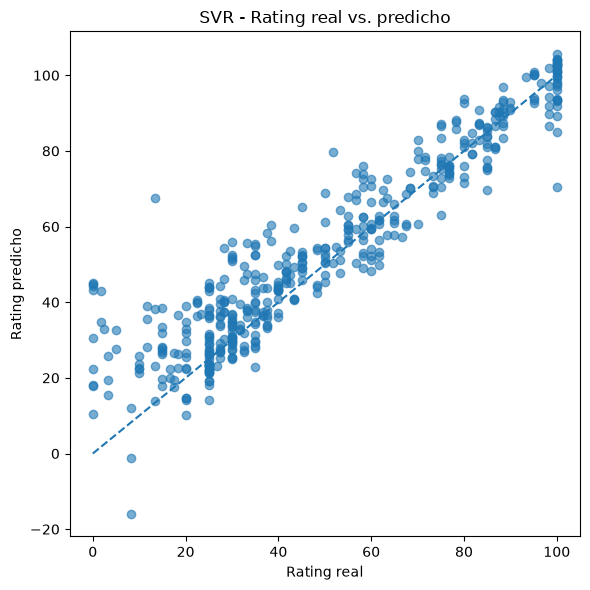

In [94]:
plt.figure(figsize=(6, 6))

plt.scatter(
    svr_validation_results_df[
        "rating_score_mean_t1"
    ],
    svr_validation_results_df[
        "prediction"
    ],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")

plt.title(
    "SVR - Rating real vs. predicho"
)

plt.tight_layout()
plt.show()

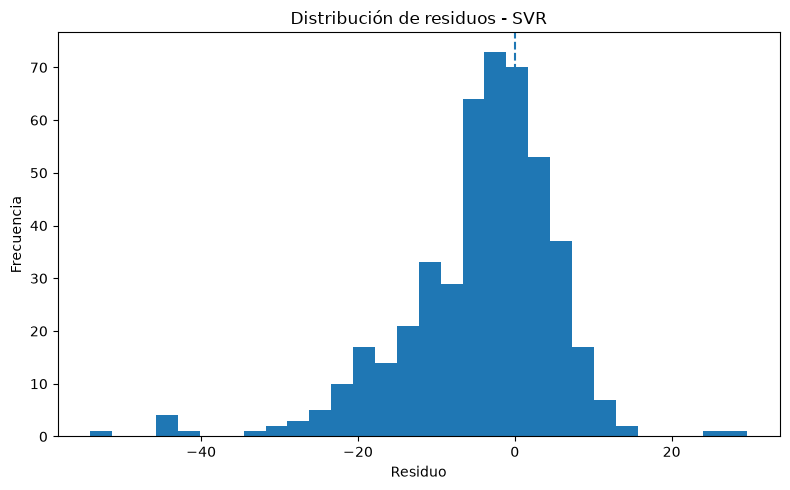

In [95]:
plt.figure(figsize=(8, 5))

plt.hist(
    svr_validation_results_df[
        "residual"
    ],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de residuos - SVR"
)

plt.tight_layout()
plt.show()

,MAE
rating_year,
2020,6.894
2021,7.064
2022,8.327


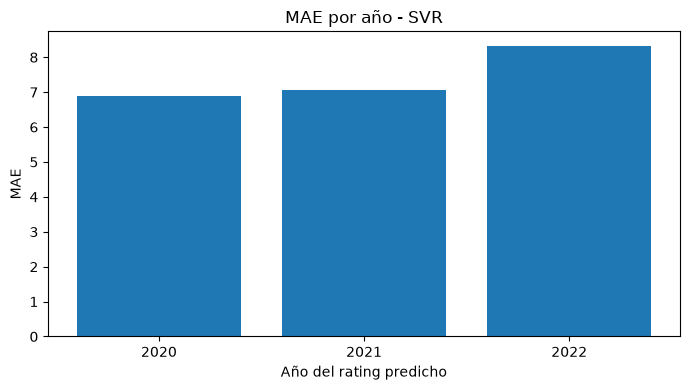

In [96]:
svr_error_year = (
    svr_validation_results_df
    .groupby(
        "rating_year"
    )["absolute_error"]
    .mean()
)

display(
    svr_error_year
    .to_frame("MAE")
    .round(3)
)

plt.figure(figsize=(7, 4))

plt.bar(
    svr_error_year.index.astype(str),
    svr_error_year.values
)

plt.xlabel(
    "Año del rating predicho"
)

plt.ylabel("MAE")

plt.title(
    "MAE por año - SVR"
)

plt.tight_layout()
plt.show()

In [97]:
worst_svr_predictions = (
    svr_validation_results_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_svr_predictions[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,67.45,54.11
1845,Lebanon,2021,2022,0.00,45.15,45.15
2655,Puerto Rico (US),2019,2020,0.00,44.69,44.69
2657,Puerto Rico (US),2021,2022,0.00,44.22,44.22
2656,Puerto Rico (US),2020,2021,0.00,43.35,43.35
409,Belarus,2021,2022,1.67,42.86,41.20
1908,Sri Lanka,2021,2022,1.67,34.82,33.15
1844,Lebanon,2020,2021,0.00,30.59,30.59
1229,Ghana,2021,2022,2.50,32.85,30.35
1980,Luxembourg,2019,2020,100.00,70.37,29.63


In [98]:
outside_svr = (
    (svr_validation_pred < 0)
    |
    (svr_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_svr.sum()
)

print(
    "Porcentaje:",
    round(
        outside_svr.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(
        svr_validation_pred.min(),
        2
    )
)

print(
    "Predicción máxima:",
    round(
        svr_validation_pred.max(),
        2
    )
)

Predicciones fuera de 0-100: 22
Porcentaje: 4.72 %
Predicción mínima: -15.87
Predicción máxima: 105.55


In [99]:
svr_permutation = permutation_importance(
    svr_model,
    X_validation_svr,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

svr_importance = pd.DataFrame({
    "variable":
        X_validation_svr.columns,

    "importance":
        svr_permutation.importances_mean
})

svr_importance = (
    svr_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    svr_importance
    .head(20)
    .round(4)
)

,variable,importance
0,regulatory_quality_estimate,3.8524
1,gdp_ppp_constant_2021_intl_usd,2.9375
2,gdp_per_capita_constant_2015_usd,1.6433
3,government_debt_pct_gdp,0.9353
4,sovereign_debt_in_default_usd_mn,0.4007
5,inflation_abs,0.3789
6,imports_pct_gdp,0.3730
7,region_Sub-Saharan Africa,0.3114
8,reserves_months_imports,0.2884
9,exports_pct_gdp,0.2883


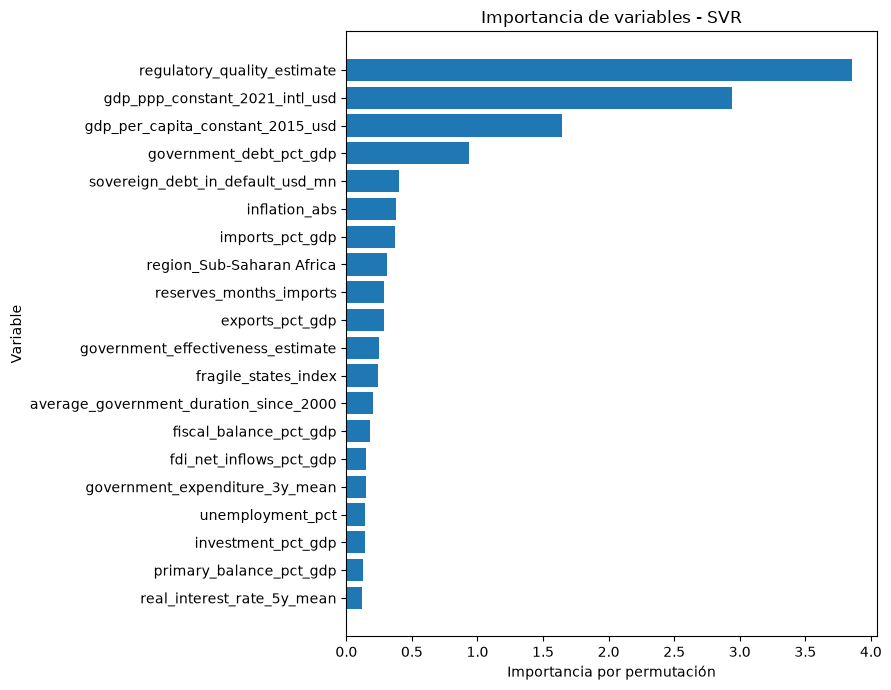

In [100]:
svr_importance_economic = (
    svr_importance[
        ~svr_importance["variable"]
        .str.startswith(
            "missingindicator_"
        )
    ]
)

top_svr_importance = (
    svr_importance_economic
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_svr_importance["variable"],
    top_svr_importance["importance"]
)

plt.xlabel(
    "Importancia por permutación"
)

plt.ylabel("Variable")

plt.title(
    "Importancia de variables - SVR"
)

plt.tight_layout()
plt.show()

El modelo Support Vector Regression con kernel RBF alcanza un MAE de 7,430, un RMSE de 10,712 y un $R^2$ de 0,852 en el conjunto de validación. Estos resultados son ligeramente inferiores a los obtenidos mediante los modelos lineales regularizados, por lo que la incorporación de relaciones no lineales mediante el kernel RBF no proporciona, en esta especificación, una mejora de la capacidad predictiva basada exclusivamente en fundamentales.

El modelo utiliza 1.799 vectores soporte, equivalentes al 72,05 % de las observaciones de entrenamiento, lo que indica que una proporción elevada de la muestra interviene directamente en la construcción de la función de predicción. El análisis temporal vuelve a identificar 2022 como el periodo con mayor dificultad predictiva, alcanzando un MAE de 8,327.

Asimismo, los mayores errores vuelven a concentrarse en países asociados a episodios económicos, financieros o geopolíticos especialmente adversos, entre ellos Rusia, Líbano, Bielorrusia, Sri Lanka y Ucrania. La persistencia de estos casos extremos entre diferentes metodologías sugiere que su dificultad de predicción no responde exclusivamente a las restricciones de los modelos lineales.

Finalmente, el 4,72 % de las predicciones se sitúa fuera del intervalo teórico 0-100. Aunque SVR reduce la magnitud de algunos valores extremos respecto a las regresiones lineales, no elimina completamente esta limitación.

In [101]:
X_train_svr_rating = X_train_lasso_rating.copy()
X_validation_svr_rating = X_validation_lasso_rating.copy()

y_train_svr_rating = y_train_lasso_rating.copy()
y_validation_svr_rating = y_validation_lasso_rating.copy()

In [102]:
svr_rating_results = []

for C in svr_C_values:

    for epsilon in svr_epsilon_values:

        for gamma in svr_gamma_values:

            model = SVR(
                kernel="rbf",
                C=C,
                epsilon=epsilon,
                gamma=gamma
            )

            model.fit(
                X_train_svr_rating,
                y_train_svr_rating
            )

            pred = model.predict(
                X_validation_svr_rating
            )

            metrics = evaluate_model(
                y_validation_svr_rating,
                pred
            )

            svr_rating_results.append({
                "C": C,
                "epsilon": epsilon,
                "gamma": gamma,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "support_vectors": len(
                    model.support_
                )
            })

svr_rating_validation_results = pd.DataFrame(
    svr_rating_results
)

best_svr_rating_row = (
    svr_rating_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_svr_rating_C = (
    best_svr_rating_row["C"]
)

best_svr_rating_epsilon = (
    best_svr_rating_row["epsilon"]
)

best_svr_rating_gamma = (
    best_svr_rating_row["gamma"]
)

display(
    best_svr_rating_row
    .to_frame()
    .T
)

,C,epsilon,gamma,MAE,RMSE,R2,support_vectors
49,100,0.1,0.001,2.914664,5.99707,0.953523,2288


In [103]:
svr_model_rating = SVR(
    kernel="rbf",
    C=best_svr_rating_C,
    epsilon=best_svr_rating_epsilon,
    gamma=best_svr_rating_gamma
)

svr_model_rating.fit(
    X_train_svr_rating,
    y_train_svr_rating
)

svr_validation_pred_rating = (
    svr_model_rating.predict(
        X_validation_svr_rating
    )
)

svr_results_rating = evaluate_model(
    y_validation_svr_rating,
    svr_validation_pred_rating
)

In [104]:
comparison_rating_svr = (
    comparison_rating_elastic.copy()
)

comparison_rating_svr.loc[
    "SVR + rating_t"
] = svr_results_rating

display(
    comparison_rating_svr.round(3)
)

,MAE,RMSE,R2
Media,25.223,28.717,-0.066
Persistencia,1.505,4.209,0.977
Fundamentales,8.478,11.761,0.821
Fundamentales + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974
SVR + rating_t,2.915,5.997,0.954


In [105]:
svr_rating_predictions = pd.Series(
    svr_validation_pred_rating,
    index=validation_rating_index
)

svr_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    svr_rating_predictions.loc[
        changed_validation.index
    ]
)

comparison_changed_svr = (
    comparison_changed_elastic.copy()
)

comparison_changed_svr.loc[
    "SVR + rating_t"
] = svr_changed_results

display(
    comparison_changed_svr.round(3)
)

,MAE,RMSE,R2
Persistencia,5.097,7.746,0.897
Fundamentales + rating_t,4.951,7.736,0.897
Ridge + rating_t,4.857,7.815,0.895
Lasso + rating_t,4.981,7.857,0.894
Elastic Net + rating_t,4.965,7.855,0.894
SVR + rating_t,5.149,8.177,0.885


### Resultados parciales de la Rama A

Los modelos desarrollados hasta este punto permiten comparar diferentes estrategias de modelización sobre una misma base preprocesada y escalada. La regresión lineal proporciona una primera referencia interpretable, mientras que Ridge, Lasso y Elastic Net introducen regularización para controlar la complejidad y la presencia de variables correlacionadas. Por su parte, SVR permite incorporar relaciones no lineales mediante el uso de un kernel RBF.

Cuando se utilizan exclusivamente variables fundamentales, las diferencias de rendimiento entre los modelos son relativamente reducidas. Lasso obtiene el menor MAE, con 7,167, mientras que Ridge presenta el menor RMSE, con 10,424. La incorporación de relaciones no lineales mediante SVR no mejora estos resultados.

La inclusión de la calificación crediticia del año anterior modifica sustancialmente la capacidad predictiva. Lasso alcanza el menor MAE global entre los modelos estimados, con 2,087, aunque ninguno consigue superar el baseline de persistencia, cuyo MAE es de 1,505.

Sin embargo, esta conclusión cambia parcialmente al analizar únicamente las observaciones en las que se produce una modificación efectiva de la calificación. En este subconjunto, Ridge alcanza un MAE de 4,857, mejorando al baseline de persistencia, cuyo MAE aumenta hasta 5,097. Este resultado muestra que las variables fundamentales contienen información adicional sobre la evolución futura del rating, aunque la elevada estabilidad interanual de las calificaciones dificulta superar a la persistencia cuando se evalúa el conjunto completo de observaciones.

Antes de cerrar la Rama A se incorpora finalmente un modelo de red neuronal, que permitirá evaluar si una estructura no lineal más flexible puede extraer patrones adicionales de las variables disponibles.

## 6. RED NEURONAL MULTICAPA (MLP)

> Sexto modelo real perteneciente a la RAMA A

El perceptrón multicapa o Multilayer Perceptron (MLP) es una red neuronal artificial formada por una capa de entrada, una o varias capas ocultas y una capa de salida.

A diferencia de los modelos lineales, la red neuronal puede aprender relaciones no lineales e interacciones complejas entre las variables explicativas sin necesidad de especificarlas previamente.

El modelo es sensible a la escala de las variables, por lo que se utiliza la base correspondiente a la Rama A, previamente imputada, transformada y escalada.

La arquitectura de la red, la intensidad de regularización y la tasa de aprendizaje se seleccionan utilizando exclusivamente el conjunto de validación. El conjunto de test permanece reservado para la evaluación final del modelo seleccionado.

In [106]:
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

X_train_mlp = X_train_ridge.copy()
X_validation_mlp = X_validation_ridge.copy()
X_test_mlp = X_test_ridge.copy()

print("Train:", X_train_mlp.shape)
print("Validation:", X_validation_mlp.shape)
print("Test:", X_test_mlp.shape)

print(
    "NaN train:",
    X_train_mlp.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_mlp.isna().sum().sum()
)

print(
    "NaN test:",
    X_test_mlp.isna().sum().sum()
)

Train: (2497, 111)
Validation: (466, 111)
Test: (471, 111)
NaN train: 0
NaN validation: 0
NaN test: 0


In [107]:
mlp_architectures = [
    (50,),
    (100,),
    (50, 25),
    (100, 50)
]

mlp_alphas = [
    0.0001,
    0.001,
    0.01
]

mlp_learning_rates = [
    0.0005,
    0.001,
    0.005
]

mlp_results = []

for architecture in mlp_architectures:

    for alpha in mlp_alphas:

        for learning_rate in mlp_learning_rates:

            model = MLPRegressor(
                hidden_layer_sizes=architecture,
                activation="relu",
                solver="adam",
                alpha=alpha,
                learning_rate_init=learning_rate,
                max_iter=2000,
                random_state=42
            )

            model.fit(
                X_train_mlp,
                y_train
            )

            pred = model.predict(
                X_validation_mlp
            )

            metrics = evaluate_model(
                y_validation,
                pred
            )

            mlp_results.append({
                "architecture": architecture,
                "alpha": alpha,
                "learning_rate": learning_rate,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "iterations": model.n_iter_
            })

mlp_validation_results = pd.DataFrame(
    mlp_results
)

In [108]:
best_mlp_row = (
    mlp_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_mlp_architecture = (
    best_mlp_row["architecture"]
)

best_mlp_alpha = (
    best_mlp_row["alpha"]
)

best_mlp_learning_rate = (
    best_mlp_row["learning_rate"]
)

print(
    "Mejor arquitectura:",
    best_mlp_architecture
)

print(
    "Mejor alpha:",
    best_mlp_alpha
)

print(
    "Mejor learning rate:",
    best_mlp_learning_rate
)

display(
    best_mlp_row
    .to_frame()
    .T
)

Mejor arquitectura: (50, 25)
Mejor alpha: 0.0001
Mejor learning rate: 0.001


,architecture,alpha,learning_rate,MAE,RMSE,R2,iterations
19,"(50, 25)",0.0001,0.001,6.055701,8.620093,0.90404,245


In [109]:
display(
    mlp_validation_results
    .sort_values("MAE")
    .head(10)
    .round(4)
)

,architecture,alpha,learning_rate,MAE,RMSE,R2,iterations
19,"(50, 25)",0.0001,0.0010,6.0557,8.6201,0.9040,245
26,"(50, 25)",0.0100,0.0050,6.1916,8.8322,0.8993,138
22,"(50, 25)",0.0010,0.0010,6.2556,8.8678,0.8984,338
21,"(50, 25)",0.0010,0.0005,6.2594,8.8291,0.8993,527
25,"(50, 25)",0.0100,0.0010,6.2846,8.7742,0.9006,350
15,"(100,)",0.0100,0.0005,6.3792,9.2608,0.8892,921
23,"(50, 25)",0.0010,0.0050,6.4297,9.1161,0.8927,155
9,"(100,)",0.0001,0.0005,6.4623,9.4638,0.8843,1145
35,"(100, 50)",0.0100,0.0050,6.4779,9.1290,0.8924,151
20,"(50, 25)",0.0001,0.0050,6.5440,9.0673,0.8938,87


In [110]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=best_mlp_architecture,
    activation="relu",
    solver="adam",
    alpha=best_mlp_alpha,
    learning_rate_init=best_mlp_learning_rate,
    max_iter=2000,
    random_state=42
)

mlp_model.fit(
    X_train_mlp,
    y_train
)

mlp_validation_pred = (
    mlp_model.predict(
        X_validation_mlp
    )
)

mlp_results_final = evaluate_model(
    y_validation,
    mlp_validation_pred
)

display(
    pd.DataFrame(
        [mlp_results_final],
        index=["MLP"]
    ).round(3)
)

,MAE,RMSE,R2
MLP,6.056,8.62,0.904


In [111]:
comparison_branch_A = (
    comparison_models_fundamentals.copy()
)

comparison_branch_A.loc[
    "MLP"
] = mlp_results_final

display(
    comparison_branch_A
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
MLP,6.056,8.620,0.904
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852
OLS depurada,8.486,11.760,0.821


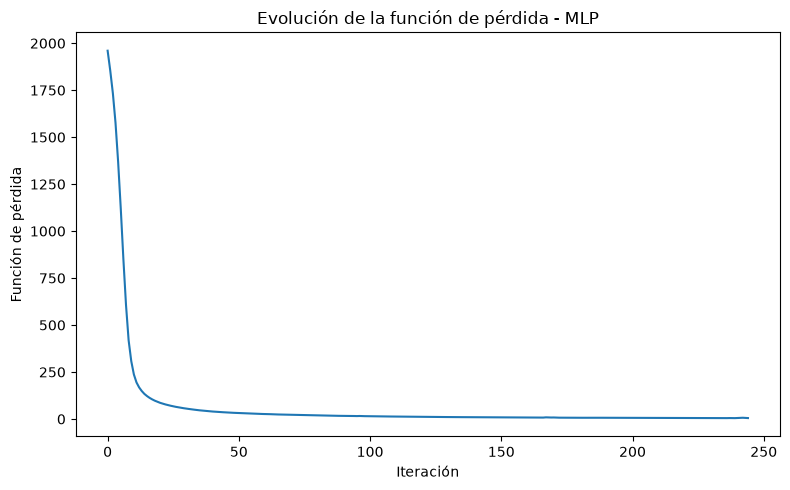

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model.loss_curve_
)

plt.xlabel("Iteración")
plt.ylabel("Función de pérdida")
plt.title(
    "Evolución de la función de pérdida - MLP"
)

plt.tight_layout()
plt.show()

In [113]:
print(
    "Iteraciones realizadas:",
    mlp_model.n_iter_
)

print(
    "Pérdida final:",
    round(
        mlp_model.loss_,
        4
    )
)

Iteraciones realizadas: 245
Pérdida final: 4.9762


In [114]:
mlp_validation_results_df = validation[
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t1"
    ]
].copy()

mlp_validation_results_df[
    "rating_year"
] = (
    mlp_validation_results_df["year"] + 1
)

mlp_validation_results_df[
    "prediction"
] = mlp_validation_pred

mlp_validation_results_df[
    "residual"
] = (
    mlp_validation_results_df[
        "rating_score_mean_t1"
    ]
    - mlp_validation_results_df[
        "prediction"
    ]
)

mlp_validation_results_df[
    "absolute_error"
] = (
    mlp_validation_results_df[
        "residual"
    ].abs()
)

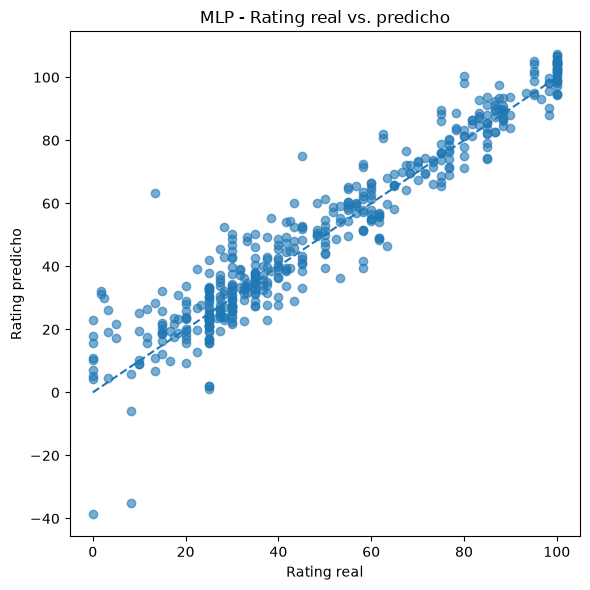

In [115]:
plt.figure(figsize=(6, 6))

plt.scatter(
    mlp_validation_results_df[
        "rating_score_mean_t1"
    ],
    mlp_validation_results_df[
        "prediction"
    ],
    alpha=0.6
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Rating real")
plt.ylabel("Rating predicho")

plt.title(
    "MLP - Rating real vs. predicho"
)

plt.tight_layout()
plt.show()

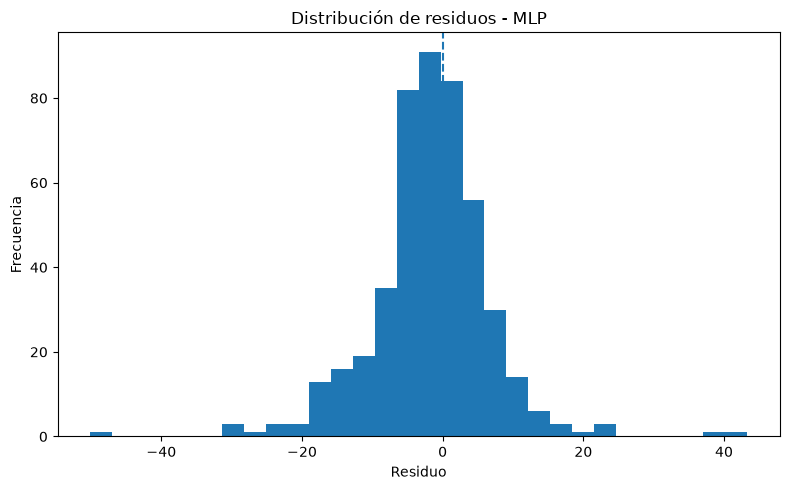

In [116]:
plt.figure(figsize=(8, 5))

plt.hist(
    mlp_validation_results_df[
        "residual"
    ],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.title(
    "Distribución de residuos - MLP"
)

plt.tight_layout()
plt.show()

In [117]:
mlp_error_year = (
    mlp_validation_results_df
    .groupby(
        "rating_year"
    )["absolute_error"]
    .mean()
)

display(
    mlp_error_year
    .to_frame("MAE")
    .round(3)
)

,MAE
rating_year,
2020,4.706
2021,6.060
2022,7.393


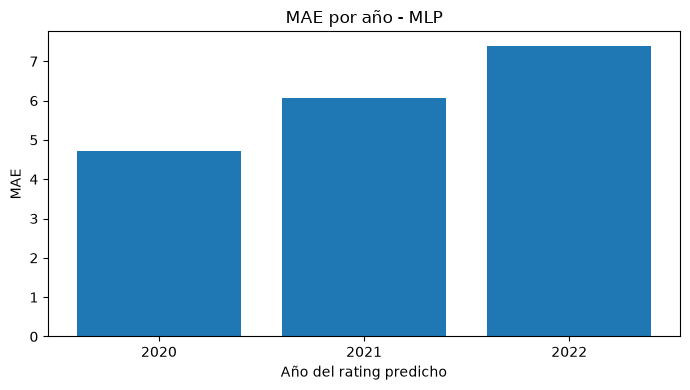

In [118]:
plt.figure(figsize=(7, 4))

plt.bar(
    mlp_error_year.index.astype(str),
    mlp_error_year.values
)

plt.xlabel(
    "Año del rating predicho"
)

plt.ylabel("MAE")

plt.title(
    "MAE por año - MLP"
)

plt.tight_layout()
plt.show()

In [119]:
worst_mlp_predictions = (
    mlp_validation_results_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
)

display(
    worst_mlp_predictions[
        [
            "country",
            "year",
            "rating_year",
            "rating_score_mean_t1",
            "prediction",
            "absolute_error"
        ]
    ].round(2)
)

,country,year,rating_year,rating_score_mean_t1,prediction,absolute_error
2782,Russian Federation,2021,2022,13.33,63.40,50.07
3380,"Venezuela, RB",2021,2022,8.33,-34.96,43.29
1845,Lebanon,2021,2022,0.00,-38.43,38.43
409,Belarus,2021,2022,1.67,32.07,30.40
2938,San Marino,2021,2022,45.00,75.14,30.14
1908,Sri Lanka,2021,2022,1.67,31.13,29.47
1229,Ghana,2021,2022,2.50,29.92,27.42
3224,Turkiye,2021,2022,28.33,52.57,24.23
2094,Maldives,2020,2021,25.00,0.94,24.06
2095,Maldives,2021,2022,25.00,1.90,23.10


In [120]:
outside_mlp = (
    (mlp_validation_pred < 0)
    |
    (mlp_validation_pred > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_mlp.sum()
)

print(
    "Porcentaje:",
    round(
        outside_mlp.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(
        mlp_validation_pred.min(),
        2
    )
)

print(
    "Predicción máxima:",
    round(
        mlp_validation_pred.max(),
        2
    )
)

Predicciones fuera de 0-100: 30
Porcentaje: 6.44 %
Predicción mínima: -38.43
Predicción máxima: 107.29


In [121]:
mlp_permutation = permutation_importance(
    mlp_model,
    X_validation_mlp,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

mlp_importance = pd.DataFrame({
    "variable":
        X_validation_mlp.columns,

    "importance":
        mlp_permutation.importances_mean
})

mlp_importance = (
    mlp_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    mlp_importance
    .head(20)
    .round(4)
)

,variable,importance
0,regulatory_quality_estimate,4.5297
1,gdp_ppp_constant_2021_intl_usd,3.1315
2,gdp_per_capita_constant_2015_usd,2.8009
3,government_debt_pct_gdp,2.6075
4,region_Sub-Saharan Africa,1.4622
5,reserves_months_imports,1.1855
6,inflation_abs,1.0035
7,income_level_Lower middle income,0.9871
8,income_level_Upper middle income,0.9404
9,imports_pct_gdp,0.7812


In [122]:
mlp_permutation = permutation_importance(
    mlp_model,
    X_validation_mlp,
    y_validation,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

mlp_importance = pd.DataFrame({
    "variable":
        X_validation_mlp.columns,

    "importance":
        mlp_permutation.importances_mean
})

mlp_importance = (
    mlp_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    mlp_importance
    .head(20)
    .round(4)
)

,variable,importance
0,regulatory_quality_estimate,4.5297
1,gdp_ppp_constant_2021_intl_usd,3.1315
2,gdp_per_capita_constant_2015_usd,2.8009
3,government_debt_pct_gdp,2.6075
4,region_Sub-Saharan Africa,1.4622
5,reserves_months_imports,1.1855
6,inflation_abs,1.0035
7,income_level_Lower middle income,0.9871
8,income_level_Upper middle income,0.9404
9,imports_pct_gdp,0.7812


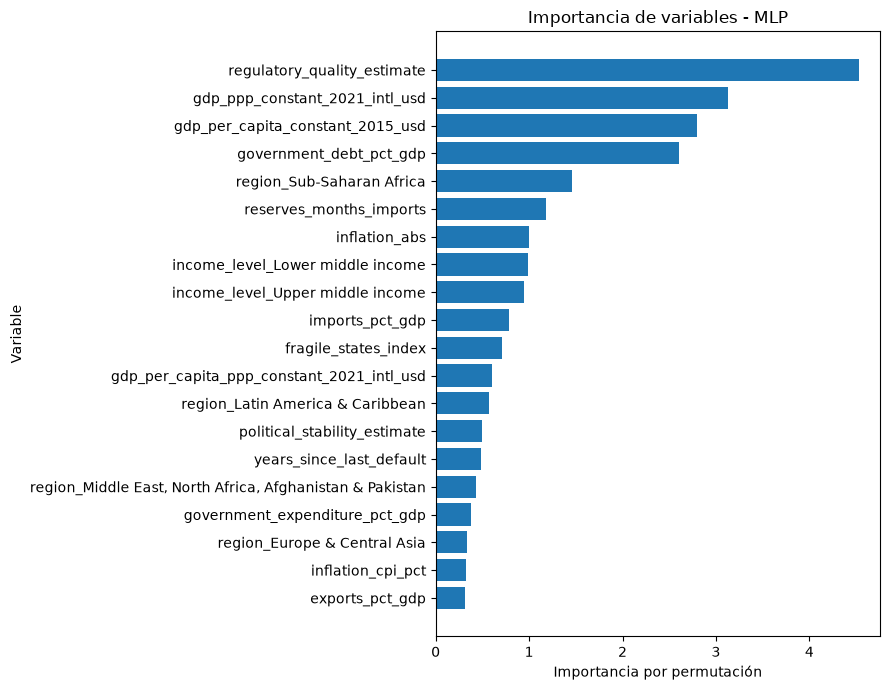

In [123]:
mlp_importance_economic = (
    mlp_importance[
        ~mlp_importance["variable"]
        .str.startswith(
            "missingindicator_"
        )
    ]
)

top_mlp_importance = (
    mlp_importance_economic
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_mlp_importance["variable"],
    top_mlp_importance["importance"]
)

plt.xlabel(
    "Importancia por permutación"
)

plt.ylabel("Variable")

plt.title(
    "Importancia de variables - MLP"
)

plt.tight_layout()
plt.show()

La red neuronal multicapa presenta una mejora sustancial respecto a los modelos anteriores cuando la predicción se realiza exclusivamente a partir de variables fundamentales. La arquitectura óptima está formada por dos capas ocultas de 50 y 25 neuronas, con un parámetro de regularización α=0,0001 y una tasa de aprendizaje de 0,001.

En el conjunto de validación, el modelo alcanza un MAE de 6,056, un RMSE de 8,620 y un R
2
 de 0,904. Estos resultados representan una mejora considerable respecto al mejor modelo anterior basado únicamente en fundamentales, Lasso, cuyo MAE era de 7,167. Por tanto, la capacidad de la red neuronal para capturar relaciones no lineales e interacciones entre las variables parece aportar información predictiva adicional que no estaba siendo aprovechada por las especificaciones lineales.

La evolución de la función de pérdida muestra una disminución rápida durante las primeras iteraciones y una estabilización progresiva posterior. El entrenamiento finaliza después de 245 iteraciones con una pérdida de 4,976, lo que sugiere una convergencia adecuada del algoritmo.

El comportamiento temporal del modelo continúa mostrando diferencias importantes entre años. El MAE aumenta desde 4,706 en 2020 hasta 6,060 en 2021 y 7,393 en 2022. Por tanto, 2022 vuelve a constituir el periodo de mayor dificultad predictiva, aunque el error alcanzado por la MLP es inferior al obtenido por varios de los modelos anteriores.

Los mayores errores continúan concentrándose en países asociados a episodios económicos, financieros o geopolíticos particularmente severos, como Rusia, Venezuela, Líbano, Bielorrusia y Sri Lanka. La reiterada aparición de estos países entre los errores extremos de diferentes modelos confirma la dificultad de anticipar únicamente mediante fundamentales observados en el año anterior cambios crediticios asociados a acontecimientos excepcionales.

El análisis de importancia por permutación identifica como principales factores predictivos la calidad regulatoria, el PIB en paridad de poder adquisitivo, el PIB per cápita, la deuda pública y las reservas internacionales. También aparecen entre las variables relevantes indicadores relacionados con inflación, fragilidad institucional, estabilidad política, gasto público e historial de default. La coincidencia de varios de estos factores con los identificados mediante los modelos anteriores refuerza su relevancia dentro de la explicación de las calificaciones soberanas.

---
Curiosidades de este modelo es que saber que falta el dato de inflación aporta más capacidad predictiva que el propio valor observado de inflación CPI en esta MLP.
Es decir problablemente la ausencia de ese dato este asociada conm una menos capacidad estadistica, insituciones más débiles, países frágiles, crisis o interrupciones en la producción de estadísticas o menos disponibilidad histórica de información.

> Resulta especialmente llamativo que el indicador de ausencia de información de inflación (missingindicator_inflation_cpi_pct) presente una importancia por permutación superior a la propia variable de inflación observada. Este resultado sugiere que el patrón de disponibilidad de información contiene capacidad predictiva adicional. La ausencia de determinados datos puede estar asociada con características estructurales de los países, como una menor capacidad estadística, fragilidad institucional o episodios de inestabilidad. Por este motivo, los indicadores de ausencia no deben interpretarse como determinantes económicos directos del rating, sino como variables que pueden estar capturando indirectamente características de los países relacionadas con su riesgo crediticio.

In [124]:
missing_cols_mlp = [
    col for col in X_train_mlp.columns
    if col.startswith("missingindicator_")
]

X_train_mlp_no_missing = (
    X_train_mlp.drop(
        columns=missing_cols_mlp
    )
)

X_validation_mlp_no_missing = (
    X_validation_mlp.drop(
        columns=missing_cols_mlp
    )
)

mlp_no_missing = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42
)

mlp_no_missing.fit(
    X_train_mlp_no_missing,
    y_train
)

mlp_no_missing_pred = (
    mlp_no_missing.predict(
        X_validation_mlp_no_missing
    )
)

mlp_no_missing_results = evaluate_model(
    y_validation,
    mlp_no_missing_pred
)

comparison_missing_mlp = pd.DataFrame({
    "MLP con indicadores missing":
        mlp_results_final,
    "MLP sin indicadores missing":
        mlp_no_missing_results
}).T

display(
    comparison_missing_mlp.round(3)
)

,MAE,RMSE,R2
MLP con indicadores missing,6.056,8.620,0.904
MLP sin indicadores missing,7.546,10.107,0.868


Dada la elevada importancia obtenida por algunos indicadores de ausencia de información, se realizó adicionalmente un análisis de sensibilidad eliminando todos los missing indicators de la base utilizada por la red neuronal. El rendimiento se deterioró de forma considerable: el MAE aumentó de 6,056 a 7,546, mientras que el R
2
 disminuyó de 0,904 a 0,868. Esto supone un incremento aproximado del 24,6 % en el error absoluto medio.

Este resultado confirma que los patrones de ausencia de información contienen capacidad predictiva relevante para la red neuronal. Su interpretación, sin embargo, debe realizarse con cautela. Estos indicadores no representan factores económicos directamente causales, sino que pueden actuar como proxies de características estructurales de los países, como la capacidad estadística, la calidad institucional, la disponibilidad de información o determinados episodios de inestabilidad.

Por este motivo, los indicadores de ausencia se mantienen en la especificación definitiva de la MLP, dado que su eliminación provoca una pérdida sustancial de capacidad predictiva.

### MLP + rainting_t

In [125]:
X_train_mlp_rating = (
    X_train_lasso_rating.copy()
)

X_validation_mlp_rating = (
    X_validation_lasso_rating.copy()
)

y_train_mlp_rating = (
    y_train_lasso_rating.copy()
)

y_validation_mlp_rating = (
    y_validation_lasso_rating.copy()
)

print(
    "Train:",
    X_train_mlp_rating.shape
)

print(
    "Validation:",
    X_validation_mlp_rating.shape
)

print(
    "NaN train:",
    X_train_mlp_rating.isna().sum().sum()
)

print(
    "NaN validation:",
    X_validation_mlp_rating.isna().sum().sum()
)

Train: (2440, 112)
Validation: (464, 112)
NaN train: 0
NaN validation: 0


In [126]:
mlp_rating_results = []

for architecture in mlp_architectures:

    for alpha in mlp_alphas:

        for learning_rate in mlp_learning_rates:

            model = MLPRegressor(
                hidden_layer_sizes=architecture,
                activation="relu",
                solver="adam",
                alpha=alpha,
                learning_rate_init=learning_rate,
                max_iter=2000,
                random_state=42
            )

            model.fit(
                X_train_mlp_rating,
                y_train_mlp_rating
            )

            pred = model.predict(
                X_validation_mlp_rating
            )

            metrics = evaluate_model(
                y_validation_mlp_rating,
                pred
            )

            mlp_rating_results.append({
                "architecture": architecture,
                "alpha": alpha,
                "learning_rate": learning_rate,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "iterations": model.n_iter_
            })

mlp_rating_validation_results = pd.DataFrame(
    mlp_rating_results
)

In [127]:
best_mlp_rating_row = (
    mlp_rating_validation_results
    .sort_values("MAE")
    .iloc[0]
)

best_mlp_rating_architecture = (
    best_mlp_rating_row["architecture"]
)

best_mlp_rating_alpha = (
    best_mlp_rating_row["alpha"]
)

best_mlp_rating_learning_rate = (
    best_mlp_rating_row["learning_rate"]
)

print(
    "Mejor arquitectura:",
    best_mlp_rating_architecture
)

print(
    "Mejor alpha:",
    best_mlp_rating_alpha
)

print(
    "Mejor learning rate:",
    best_mlp_rating_learning_rate
)

display(
    best_mlp_rating_row
    .to_frame()
    .T
)

Mejor arquitectura: (50,)
Mejor alpha: 0.01
Mejor learning rate: 0.001


,architecture,alpha,learning_rate,MAE,RMSE,R2,iterations
7,"(50,)",0.01,0.001,3.56096,5.338124,0.963176,542


In [128]:
display(
    mlp_rating_validation_results
    .sort_values("MAE")
    .head(10)
    .round(4)
)

,architecture,alpha,learning_rate,MAE,RMSE,R2,iterations
7,"(50,)",0.0100,0.0010,3.5610,5.3381,0.9632,542
4,"(50,)",0.0010,0.0010,3.6160,5.3919,0.9624,542
3,"(50,)",0.0010,0.0005,3.6580,5.6012,0.9595,1109
6,"(50,)",0.0100,0.0005,3.6672,5.6073,0.9594,1109
1,"(50,)",0.0001,0.0010,3.7260,5.7517,0.9572,708
0,"(50,)",0.0001,0.0005,3.7381,5.7288,0.9576,1109
16,"(100,)",0.0100,0.0010,3.7506,5.7937,0.9566,508
13,"(100,)",0.0010,0.0010,3.8595,5.6990,0.9580,399
10,"(100,)",0.0001,0.0010,3.8955,5.7191,0.9577,399
23,"(50, 25)",0.0010,0.0050,3.9045,5.7458,0.9573,91


In [129]:
mlp_model_rating = MLPRegressor(
    hidden_layer_sizes=
        best_mlp_rating_architecture,
    activation="relu",
    solver="adam",
    alpha=best_mlp_rating_alpha,
    learning_rate_init=
        best_mlp_rating_learning_rate,
    max_iter=2000,
    random_state=42
)

mlp_model_rating.fit(
    X_train_mlp_rating,
    y_train_mlp_rating
)

mlp_validation_pred_rating = (
    mlp_model_rating.predict(
        X_validation_mlp_rating
    )
)

mlp_results_rating = evaluate_model(
    y_validation_mlp_rating,
    mlp_validation_pred_rating
)

display(
    pd.DataFrame(
        [mlp_results_rating],
        index=["MLP + rating_t"]
    ).round(3)
)

,MAE,RMSE,R2
MLP + rating_t,3.561,5.338,0.963


In [130]:
comparison_rating_mlp = (
    comparison_rating_svr.copy()
)

comparison_rating_mlp.loc[
    "MLP + rating_t"
] = mlp_results_rating

display(
    comparison_rating_mlp
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Persistencia,1.505,4.209,0.977
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974
Fundamentales + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
SVR + rating_t,2.915,5.997,0.954
MLP + rating_t,3.561,5.338,0.963
Fundamentales,8.478,11.761,0.821
Media,25.223,28.717,-0.066


In [131]:
mlp_rating_predictions = pd.Series(
    mlp_validation_pred_rating,
    index=validation_rating_index
)

mlp_changed_results = evaluate_model(
    changed_validation[
        "rating_score_mean_t1"
    ],
    mlp_rating_predictions.loc[
        changed_validation.index
    ]
)

comparison_changed_mlp = (
    comparison_changed_svr.copy()
)

comparison_changed_mlp.loc[
    "MLP + rating_t"
] = mlp_changed_results

display(
    comparison_changed_mlp
    .sort_values("MAE")
    .round(3)
)

,MAE,RMSE,R2
Ridge + rating_t,4.857,7.815,0.895
Fundamentales + rating_t,4.951,7.736,0.897
Elastic Net + rating_t,4.965,7.855,0.894
Lasso + rating_t,4.981,7.857,0.894
Persistencia,5.097,7.746,0.897
SVR + rating_t,5.149,8.177,0.885
MLP + rating_t,5.689,8.021,0.889


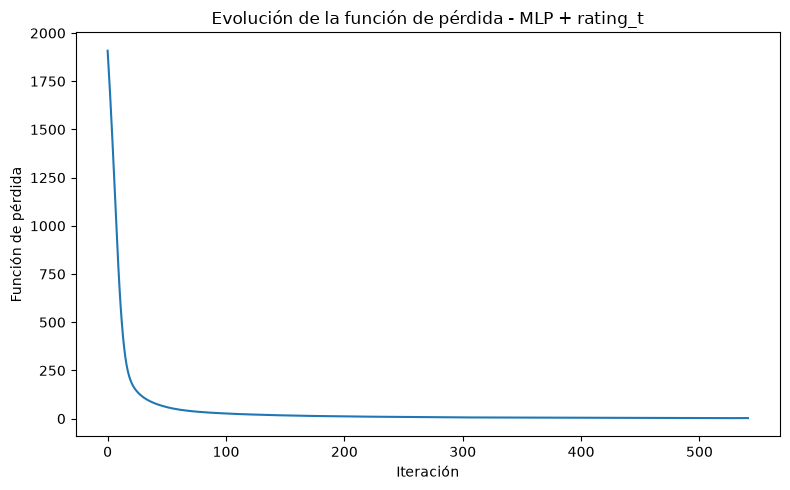

In [132]:
plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model_rating.loss_curve_
)

plt.xlabel("Iteración")
plt.ylabel("Función de pérdida")

plt.title(
    "Evolución de la función de pérdida - MLP + rating_t"
)

plt.tight_layout()
plt.show()

In [133]:
print(
    "Iteraciones:",
    mlp_model_rating.n_iter_
)

print(
    "Pérdida final:",
    round(
        mlp_model_rating.loss_,
        4
    )
)

Iteraciones: 542
Pérdida final: 2.6861


In [134]:
mlp_rating_validation_df = validation.loc[
    validation_rating_index,
    [
        "iso3",
        "country",
        "year",
        "rating_score_mean_t",
        "rating_score_mean_t1"
    ]
].copy()

mlp_rating_validation_df[
    "rating_year"
] = (
    mlp_rating_validation_df["year"] + 1
)

mlp_rating_validation_df[
    "prediction"
] = mlp_validation_pred_rating

mlp_rating_validation_df[
    "residual"
] = (
    mlp_rating_validation_df[
        "rating_score_mean_t1"
    ]
    - mlp_rating_validation_df[
        "prediction"
    ]
)

mlp_rating_validation_df[
    "absolute_error"
] = (
    mlp_rating_validation_df[
        "residual"
    ].abs()
)

mlp_rating_error_year = (
    mlp_rating_validation_df
    .groupby(
        "rating_year"
    )["absolute_error"]
    .mean()
)

display(
    mlp_rating_error_year
    .to_frame("MAE")
    .round(3)
)

,MAE
rating_year,
2020,3.055
2021,3.636
2022,3.989


In [135]:
outside_mlp_rating = (
    (mlp_validation_pred_rating < 0)
    |
    (mlp_validation_pred_rating > 100)
)

print(
    "Predicciones fuera de 0-100:",
    outside_mlp_rating.sum()
)

print(
    "Porcentaje:",
    round(
        outside_mlp_rating.mean() * 100,
        2
    ),
    "%"
)

print(
    "Predicción mínima:",
    round(
        mlp_validation_pred_rating.min(),
        2
    )
)

print(
    "Predicción máxima:",
    round(
        mlp_validation_pred_rating.max(),
        2
    )
)

Predicciones fuera de 0-100: 25
Porcentaje: 5.39 %
Predicción mínima: -14.91
Predicción máxima: 104.52


In [136]:
mlp_rating_permutation = permutation_importance(
    mlp_model_rating,
    X_validation_mlp_rating,
    y_validation_mlp_rating,
    scoring="neg_mean_absolute_error",
    n_repeats=20,
    random_state=42
)

mlp_rating_importance = pd.DataFrame({
    "variable":
        X_validation_mlp_rating.columns,

    "importance":
        mlp_rating_permutation.importances_mean
})

mlp_rating_importance = (
    mlp_rating_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    mlp_rating_importance
    .head(25)
    .round(4)
)

,variable,importance
0,rating_score_mean_t,20.8464
1,years_since_last_default,1.8779
2,gdp_per_capita_constant_2015_usd,1.0714
3,region_Europe & Central Asia,0.7112
4,income_level_Lower middle income,0.6218
5,gdp_ppp_constant_2021_intl_usd,0.6159
6,income_level_Upper middle income,0.4778
7,regulatory_quality_estimate,0.3990
8,missingindicator_inflation_cpi_pct,0.3924
9,government_debt_pct_gdp,0.3506


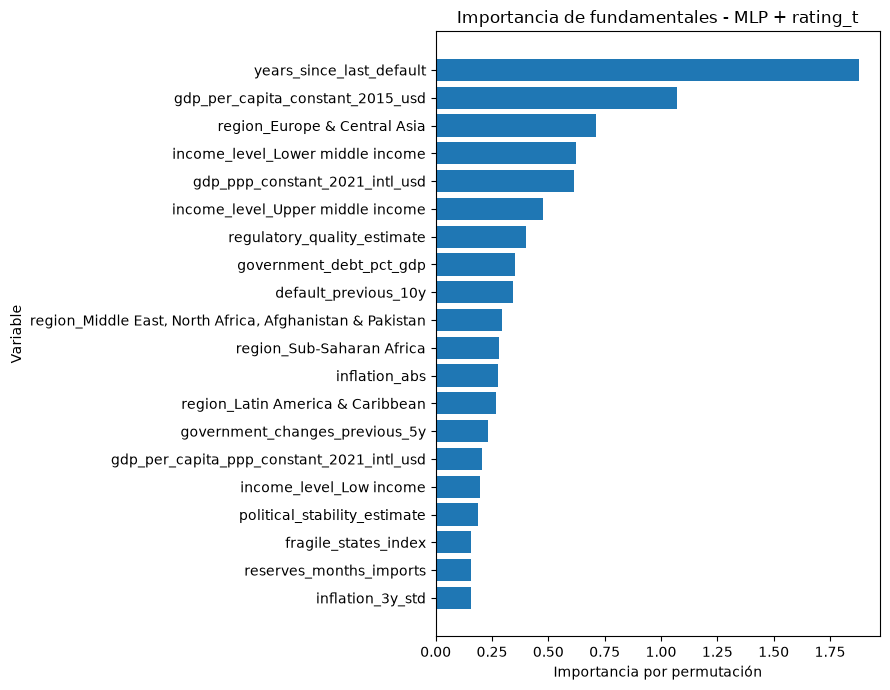

In [137]:
mlp_rating_importance_fundamentals = (
    mlp_rating_importance[
        (
            mlp_rating_importance["variable"]
            != "rating_score_mean_t"
        )
        &
        (
            ~mlp_rating_importance["variable"]
            .str.startswith(
                "missingindicator_"
            )
        )
    ]
)

top_mlp_rating_importance = (
    mlp_rating_importance_fundamentals
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_mlp_rating_importance["variable"],
    top_mlp_rating_importance["importance"]
)

plt.xlabel(
    "Importancia por permutación"
)

plt.ylabel("Variable")

plt.title(
    "Importancia de fundamentales - MLP + rating_t"
)

plt.tight_layout()
plt.show()

La incorporación de la calificación crediticia previa modifica considerablemente el comportamiento de la red neuronal. La configuración óptima corresponde a una única capa oculta de 50 neuronas, con un parámetro de regularización α=0,01 y una tasa de aprendizaje de 0,001. El modelo converge después de 542 iteraciones, alcanzando una pérdida final de 2,686.

En el conjunto de validación, la MLP con rating previo obtiene un MAE de 3,561, un RMSE de 5,338 y un R
2
 de 0,963. La incorporación del rating vigente mejora de forma considerable el rendimiento respecto a la MLP basada únicamente en fundamentales, cuyo MAE era de 6,056. Sin embargo, esta especificación no consigue superar a los modelos lineales regularizados que también incorporan el rating previo. Lasso continúa presentando el menor MAE entre los modelos estimados, con 2,087, seguido de Elastic Net, con 2,116.

La diferencia resulta todavía más evidente cuando el análisis se restringe a las observaciones en las que efectivamente se produce un cambio de calificación. En estos casos, la MLP obtiene un MAE de 5,689, superior tanto al baseline de persistencia, con 5,097, como al mejor resultado obtenido por Ridge, con 4,857. Por tanto, aunque la red neuronal presenta una elevada capacidad para explicar el nivel general de las calificaciones, no muestra una ventaja específica para anticipar sus modificaciones.

El análisis de importancia por permutación confirma el fuerte predominio del rating previo, cuya importancia alcanza 20,846, muy por encima de cualquier otro predictor. Entre los fundamentales, destacan el número de años transcurridos desde el último default, el PIB per cápita, el PIB PPA, la calidad regulatoria, la deuda pública y distintos indicadores relacionados con el historial de impago y la inflación.

Resulta nuevamente relevante la presencia de indicadores de ausencia de información. En particular, missingindicator_inflation_cpi_pct alcanza una importancia de 0,392, similar a la calidad regulatoria (0,399) y superior a la deuda pública (0,351). Este resultado es coherente con el análisis de sensibilidad realizado anteriormente, que mostró una pérdida importante de capacidad predictiva al eliminar conjuntamente los indicadores de ausencia de información. Estos indicadores se mantienen, por tanto, como predictores útiles, aunque su interpretación debe entenderse como información indirecta sobre las características de los países y no como relaciones económicas causales.

Por años, el MAE aumenta progresivamente desde 3,055 en 2020 hasta 3,636 en 2021 y 3,989 en 2022, manteniéndose nuevamente 2022 como el periodo de mayor dificultad predictiva. Finalmente, el 5,39 % de las predicciones se sitúa fuera del intervalo teórico 0-100, con valores comprendidos entre -14,91 y 104,52.

In [140]:
comparison_branch_A_final = (
    comparison_branch_A
    .sort_values("MAE")
    .copy()
)

display(
    comparison_branch_A_final.round(3)
)

,MAE,RMSE,R2
MLP,6.056,8.620,0.904
Lasso,7.167,10.586,0.855
Elastic Net,7.179,10.586,0.855
OLS original,7.261,10.456,0.859
Ridge,7.265,10.424,0.860
SVR,7.430,10.712,0.852
OLS depurada,8.486,11.760,0.821


In [141]:
comparison_rating_A_final = (
    comparison_rating_mlp
    .rename(
        index={
            "Fundamentales + rating_t":
                "OLS + rating_t"
        }
    )
    .drop(
        index=[
            "Media",
            "Fundamentales"
        ],
        errors="ignore"
    )
    .sort_values("MAE")
)

display(
    comparison_rating_A_final.round(3)
)

,MAE,RMSE,R2
Persistencia,1.505,4.209,0.977
Lasso + rating_t,2.087,4.432,0.975
Elastic Net + rating_t,2.116,4.452,0.974
OLS + rating_t,2.402,4.520,0.974
Ridge + rating_t,2.479,4.618,0.972
SVR + rating_t,2.915,5.997,0.954
MLP + rating_t,3.561,5.338,0.963


In [142]:
comparison_changed_A_final = (
    comparison_changed_mlp
    .rename(
        index={
            "Fundamentales + rating_t":
                "OLS + rating_t"
        }
    )
    .sort_values("MAE")
)

display(
    comparison_changed_A_final.round(3)
)

,MAE,RMSE,R2
Ridge + rating_t,4.857,7.815,0.895
OLS + rating_t,4.951,7.736,0.897
Elastic Net + rating_t,4.965,7.855,0.894
Lasso + rating_t,4.981,7.857,0.894
Persistencia,5.097,7.746,0.897
SVR + rating_t,5.149,8.177,0.885
MLP + rating_t,5.689,8.021,0.889


## Conclusiones de la Rama A

La Rama A ha permitido comparar seis familias de modelos sensibles a la escala de las variables: regresión lineal, Ridge, Lasso, Elastic Net, Support Vector Regression y una red neuronal multicapa.

Cuando la predicción se realiza exclusivamente mediante variables fundamentales, la red neuronal MLP presenta claramente el mejor comportamiento. El modelo alcanza un MAE de 6,056, un RMSE de 8,620 y un R² de 0,904, mejorando considerablemente al resto de metodologías. Este resultado sugiere que existen relaciones no lineales e interacciones entre los fundamentales que no son completamente capturadas mediante las especificaciones lineales.

El análisis de importancia de variables muestra además una elevada recurrencia de determinados grupos de factores entre los diferentes modelos. Los indicadores institucionales, el tamaño y nivel de desarrollo económico, la deuda pública, la posición fiscal, las reservas, la inflación y el historial de default aparecen repetidamente entre las variables con mayor capacidad explicativa o predictiva.

La incorporación de la calificación crediticia vigente mejora sustancialmente el rendimiento de todos los modelos. Entre las metodologías estimadas, Lasso obtiene el menor MAE global, con 2,087, seguido de Elastic Net, con 2,116. Sin embargo, ninguno de los modelos de la Rama A consigue superar globalmente al baseline de persistencia, cuyo MAE es de 1,505. Este resultado refleja la elevada estabilidad interanual de las calificaciones crediticias soberanas.

La elevada capacidad predictiva de la persistencia no implica, sin embargo, que los fundamentales carezcan de información sobre la evolución futura del rating. Cuando el análisis se restringe a las observaciones en las que efectivamente se produce una modificación de la calificación, Ridge obtiene un MAE de 4,857, mejorando al baseline de persistencia, cuyo MAE aumenta hasta 5,097. También OLS, Lasso y Elastic Net consiguen mejorar ligeramente este benchmark.

Por tanto, los resultados de la Rama A sugieren una distinción importante entre la predicción del nivel y la predicción de los cambios de rating. El nivel futuro de la calificación está fuertemente condicionado por su valor actual, mientras que determinadas variables fundamentales aportan información adicional cuando se producen modificaciones efectivas de la calidad crediticia.

Finalmente, el análisis de la MLP ha mostrado que los patrones de ausencia de información también contienen capacidad predictiva. La eliminación de los indicadores de missingness aumentó el MAE desde 6,056 hasta 7,546, lo que confirma que estos patrones contienen información relevante, aunque deben interpretarse como indicadores indirectos de características estructurales de los países y no como relaciones económicas causales.

Una vez finalizados los modelos sensibles a la escala, el análisis continúa con la Rama B, dedicada a métodos basados en árboles y ensembles.

In [143]:
branch_A_results = {
    
    # Tablas finales
    "comparison_fundamentals":
        comparison_branch_A_final,
    
    "comparison_rating":
        comparison_rating_A_final,
    
    "comparison_changed":
        comparison_changed_A_final,

    # Resultados principales
    "ridge_results":
        ridge_results_final,
    
    "lasso_results":
        lasso_results_final,
    
    "elastic_results":
        elastic_results_final,
    
    "svr_results":
        svr_results_final,
    
    "mlp_results":
        mlp_results_final,

    # Resultados con rating_t
    "ridge_rating_results":
        ridge_results_rating,
    
    "lasso_rating_results":
        lasso_results_rating,
    
    "elastic_rating_results":
        elastic_results_rating,
    
    "svr_rating_results":
        svr_results_rating,
    
    "mlp_rating_results":
        mlp_results_rating,

    # Mejores hiperparámetros
    "best_ridge_alpha":
        best_ridge_alpha,

    "best_ridge_rating_alpha":
        best_ridge_rating_alpha,

    "best_lasso_alpha":
        best_lasso_alpha,

    "best_lasso_rating_alpha":
        best_lasso_rating_alpha,

    "best_elastic_alpha":
        best_elastic_alpha,

    "best_elastic_l1_ratio":
        best_elastic_l1_ratio,

    "best_elastic_rating_alpha":
        best_elastic_rating_alpha,

    "best_elastic_rating_l1_ratio":
        best_elastic_rating_l1_ratio,

    "best_svr_C":
        best_svr_C,

    "best_svr_epsilon":
        best_svr_epsilon,

    "best_svr_gamma":
        best_svr_gamma,

    "best_mlp_architecture":
        best_mlp_architecture,

    "best_mlp_alpha":
        best_mlp_alpha,

    "best_mlp_learning_rate":
        best_mlp_learning_rate,

    "best_mlp_rating_architecture":
        best_mlp_rating_architecture,

    "best_mlp_rating_alpha":
        best_mlp_rating_alpha,

    "best_mlp_rating_learning_rate":
        best_mlp_rating_learning_rate
}

In [144]:
BRANCH_A_FILE = (
    MODEL_DATA_PATH
    / "notebook_4_2_branch_A_results.joblib"
)

joblib.dump(
    branch_A_results,
    BRANCH_A_FILE
)

print(
    "Resultados de Rama A guardados en:",
    BRANCH_A_FILE
)

Resultados de Rama A guardados en: data\model\notebook_4_2_branch_A_results.joblib


In [145]:
print(
    [
        key
        for key in data_41.keys()
        if "_B" in key
    ]
)

[]
